<a href="https://colab.research.google.com/github/Jittiphat-s/Machine_learning/blob/main/(IPD_Data%2BOPD_Cul)_%E0%B8%8A%E0%B8%B7%E0%B9%88%E0%B8%AD%E0%B9%80%E0%B8%8A%E0%B8%B7%E0%B9%89%E0%B8%AD%2B%E0%B8%8A%E0%B8%B7%E0%B9%88%E0%B8%AD%E0%B8%A2%E0%B8%B2_%2B_Specimen_%2B_%E0%B9%80%E0%B8%9E%E0%B8%A8_%2B_%E0%B8%AD%E0%B8%B2%E0%B8%A2%E0%B8%B8_%2B_%E0%B8%AB%E0%B8%AD%E0%B8%9C%E0%B8%B9%E0%B9%89%E0%B8%9B%E0%B9%88%E0%B8%A7%E0%B8%A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 1 : IMPORT & LOAD DATA

##Step1.1ติดตั้งไลบารี่

In [ ]:
!pip install fuzzywuzzy
!pip install python-Levenshtein

!pip install openpyxl
!pip install rapidfuzz


##Step1.2 โหลดไลบรารี + ตั้งค่า BASE / encoding

โหลดไลบรารีที่ใช้ (re/numpy/pandas/openpyxl), ตั้งค่า BASE และ encoding (ENC_IPD_DATA, ENC_CULTURE) และเตรียมฟังก์ชัน normalize_columns() เพื่อทำให้ชื่อคอลัมน์เป็นตัวพิมพ์เล็กและตัดช่องว่าง

In [ ]:
import re                                  # เรียกความสามารถจัดการตัวหนังสือแบบมีแบบแผน เช่น เอาตัวอักษรในวงเล็บออก
import numpy as np                         # เรียกความสามารถคำนวณจำนวนและค่าที่ว่าง
import pandas as pd                        # เรียกความสามารถจัดการตารางข้อมูล
from openpyxl import Workbook              # เรียกความสามารถสร้างไฟล์ตารางแบบเปิดในโปรแกรมตารางได้
from openpyxl.styles import PatternFill, Alignment  # เรียกความสามารถเติมสีพื้นหลังและจัดการวางข้อความในตาราง
from openpyxl.utils.dataframe import dataframe_to_rows  # เรียกความสามารถแปลงตารางให้กลายเป็นแถวสำหรับเขียนลงไฟล์

BASE = "/content/drive/MyDrive/Colab Notebooks/FileDATA"  # ระบุโฟลเดอร์ที่วางไฟล์ข้อมูลของเรา
ENC_IPD_DATA = "utf-8-sig"                 # ระบุรูปแบบตัวหนังสือสำหรับไฟล์ข้อมูลผู้ป่วย (อ่านภาษาไทยได้ดี)
ENC_CULTURE  = "iso8859_11"                # ระบุรูปแบบตัวหนังสือสำหรับไฟล์ผลเพาะเชื้อที่เป็นของเก่า (อ่านไทยเก่าได้)

def normalize_columns(df):
    df.columns = df.columns.str.lower().str.strip()
    return df

##Step1.3 อ่านไฟล์ IPD_Data, IPD_Cul, OPD_Cul

* อ่าน IPD_Data.txt ด้วยตัวคั่นแท็บ (sep="\t") และ encoding=ENC_IPD_DATA จากนั้น normalize ชื่อคอลัมน์ และคัดเฉพาะคอลัมน์สำคัญไว้สำหรับ enrich (เช่น เพศ อายุ vn/an/วันที่)

* อ่าน IPD_Cul02.txt (หรือชื่อไฟล์ที่ใช้งานจริง) ด้วย encoding=ENC_CULTURE, ปรับชื่อคอลัมน์ และคัดคอลัมน์ที่จำเป็นในการวิเคราะห์ เช่น (hn/an/vn, org, anti/anti_name, anti_result, anti_mic, date_r, time_r, lst/rep เป็นต้น)

* อ่านไฟล์ OPD culture และปรับชื่อคอลัมน์ให้สอดคล้องกับ IPD (รวมถึง vn) เพื่อเตรียมรวมเป็นฐานเดียวกัน

In [ ]:
def _read_ipd_data(path, enc):
    try:
        df = pd.read_csv(path, sep=",", encoding=enc, low_memory=False)
        if df.shape[1] == 1:
            df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    df = normalize_columns(df)

    # Cleaning เบื้องต้น
    if 'sex' in df.columns:
        df['sex'] = df['sex'].str.strip().replace({'ชาย':'Male','หญิง':'Female'})
    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
    return df

def _read_culture(path, enc):
    try:
        df = pd.read_csv(path, sep=",", encoding=enc, low_memory=False)
        if df.shape[1] == 1:
            df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep="\t", encoding=enc, low_memory=False)
    df = normalize_columns(df)

    # ✅ Cleaning เบื้องต้น
    if 'anti_result' in df.columns:
        df['anti_result'] = (
            df['anti_result']
            .astype(str).str.strip().str.upper()
            .replace({
                'NAN': np.nan,   # ตัวใหญ่
                'nan': np.nan,   # ตัวเล็ก
                'NONE': np.nan,  # คำว่า None
                '': np.nan       # ช่องว่าง
            })
        )
    if 'date_r' in df.columns:
        df['date_r'] = pd.to_datetime(df['date_r'], errors='coerce')
    if 'time_r' in df.columns:
        s = df['time_r'].astype(str).str.strip()
        df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')
    return df


# อ่านและ clean แยก
df_ipd_data = _read_ipd_data(f"{BASE}/IPD_Data.txt", ENC_IPD_DATA)
df_ipd_cul  = _read_culture(f"{BASE}/IPD_Cul02.txt", ENC_CULTURE)
df_opd_cul  = _read_culture(f"{BASE}/OPD_Cul.txt", ENC_CULTURE)


/tmp/ipykernel_148/3394319377.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')
/tmp/ipykernel_148/3394319377.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_r'] = pd.to_datetime(s, errors='coerce').dt.strftime('%H:%M:%S')


In [ ]:
cols_ipd_data = [                         # บอกว่าจากข้อมูลผู้ป่วย เราต้องการคอลัมน์ไหนบ้าง
    'vn','an','hn','sex','age','nat_code','nat','ward_admit_code','ward_dc_code','spc_code'
]

cols_ipd_cul = [                          # บอกว่าจากผลเพาะเชื้อ (ผู้ป่วยใน) เราต้องการคอลัมน์ไหนบ้าง
    'an','barcode','code','specimen','mb_code','org','dia','anti','anti_name','anti_result','anti_mic','date_r','time_r','lst','rep'
]

cols_opd_cul = [                          # บอกว่าจากผลเพาะเชื้อ (ผู้ป่วยนอก) เราต้องการคอลัมน์ไหนบ้าง
    'vn','barcode','code','specimen','mb_code','org','dia','anti','anti_name','anti_result','anti_mic','date_r','time_r','lst','rep'
]

df_ipd_data_use = df_ipd_data[[c for c in cols_ipd_data if c in df_ipd_data.columns]].copy()  # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากข้อมูลผู้ป่วย
df_cul_ipd      = df_ipd_cul[[c for c in cols_ipd_cul if c in df_ipd_cul.columns]].copy()  # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากผลเพาะเชื้อผู้ป่วยใน
df_cul_opd      = df_opd_cul[[c for c in cols_opd_cul if c in df_opd_cul.columns]].copy()    # เลือกเฉพาะคอลัมน์ที่มีอยู่จริงจากผลเพาะเชื้อผู้ป่วยนอก

df_all = pd.concat([df_cul_ipd, df_cul_opd], ignore_index=True)        # นำผลเพาะเชื้อจากในและนอกมารวมเป็นตารางเดียวกัน
for c in df_all.columns:                                               # เดินดูทีละคอลัมน์ในตารางรวม
    if df_all[c].dtype == object:                                      # ถ้าเป็นชนิดตัวหนังสือ
        s = df_all[c].astype(str).str.strip()                          # แปลงเป็นตัวหนังสือและตัดช่องว่างหัวท้าย
        s = s.replace({'nan': np.nan, 'None': np.nan, '': np.nan})     # แทนคำที่เหมือนว่างให้เป็นค่าว่างจริง
        df_all[c] = s                                                  # ใส่กลับคืน

#STEP 2 : COLUMN CHECK & STRUCTURE VALIDATION

In [ ]:
# STEP 2.0 : Settings & Helper (no data changes)
import re
import pandas as pd

# คอลัมน์ขั้นต่ำที่ต้องมีในชุดเพาะเชื้อ (ตามสเปกเรา)
REQUIRED_CULTURE_COLS = ["Specimen", "Org", "Anti_name", "Anti_result"]

def check_presence_case_insensitive(df: pd.DataFrame, required_cols):
    """
    คืนรายงานว่าคอลัมน์ที่ต้องการ 'มี/ไม่มี' (เทียบแบบไม่สนตัวพิมพ์) — ไม่แก้ไข df
    return: dict { total_cols, found:[ชื่อจริงในตาราง], missing:[ชื่อที่ควรมีแต่ไม่พบ] }
    """
    cols_lower = {c.lower(): c for c in df.columns}
    found, missing = [], []
    for need in required_cols:
        hit = cols_lower.get(need.lower())
        if hit is not None:
            found.append(hit)      # ชื่อจริงที่พบ
        else:
            missing.append(need)   # ชื่อที่ควรมีแต่ไม่พบ
    return {
        "total_cols": len(df.columns),
        "found": found,
        "missing": missing
    }


##STEP 2.1 : ตรวจคอลัมน์ของ IPD_Data

In [ ]:
# แสดงรายชื่อคอลัมน์ทั้งหมดของ IPD_Data (ไม่แตะข้อมูล)
print("# IPD_Data columns:")
print(list(df_ipd_data.columns))

# ช่วยเน้นคอลัมน์ที่ 'น่าจะใช้ต่อ' เฉย ๆ (ยังไม่ใช่การ normalize)
_IPD_INTEREST_PATTERNS = [r"\bhn\b", r"\ban\b", r"\bvn\b", r"ward", r"sex|gender", r"age", r"date|time|admit"]
ipd_hits = [c for c in df_ipd_data.columns if any(re.search(p, c, flags=re.I) for p in _IPD_INTEREST_PATTERNS)]
print("# IPD_Data likely-useful columns (preview):")
print(ipd_hits)


# IPD_Data columns:
['vn', 'an', 'hn', 'sex', 'age', 'nat_code', 'nat', 'rights_used_code', 'rights_used', 'rights_main_code', 'rights_main', 'ward_admit_code', 'ward_dc_code', 'spc_code', 'spc', 'comefor_code', 'comefor', 'pt_new', 'hmain_code', 'hmain', 'dischs_code', 'dischs', 'discht_code', 'discht', 'dc_date', 'dc_time', 'adm_date', 'adm_time', 'los_day', 'los_hours']
# IPD_Data likely-useful columns (preview):
['vn', 'an', 'hn', 'sex', 'age', 'ward_admit_code', 'ward_dc_code', 'dc_date', 'dc_time', 'adm_date', 'adm_time']


##STEP 2.2 : ตรวจคอลัมน์ของ IPD_Cul / OPD_Cul

In [ ]:
presence_opd = check_presence_case_insensitive(df_opd_cul, REQUIRED_CULTURE_COLS)
presence_ipd = check_presence_case_insensitive(df_ipd_cul, REQUIRED_CULTURE_COLS)

print("# OPD_Cul presence:", presence_opd)
print("# IPD_Cul presence:", presence_ipd)


# OPD_Cul presence: {'total_cols': 15, 'found': ['specimen', 'org', 'anti_name', 'anti_result'], 'missing': []}
# IPD_Cul presence: {'total_cols': 16, 'found': ['specimen', 'org', 'anti_name', 'anti_result'], 'missing': []}


##STEP 2.3 : สรุปผลรวมเป็น COL_PRESENCE_REPORT

In [ ]:
# STEP 2.3 : Summary object — เก็บไว้ใช้อ้างอิงขั้นต่อไป
COL_PRESENCE_REPORT = {
    "REQUIRED_CULTURE_COLS": REQUIRED_CULTURE_COLS,
    "OPD_Cul": presence_opd,
    "IPD_Cul": presence_ipd,
}
COL_PRESENCE_REPORT


{'REQUIRED_CULTURE_COLS': ['Specimen', 'Org', 'Anti_name', 'Anti_result'],
 'OPD_Cul': {'total_cols': 15,
  'found': ['specimen', 'org', 'anti_name', 'anti_result'],
  'missing': []},
 'IPD_Cul': {'total_cols': 16,
  'found': ['specimen', 'org', 'anti_name', 'anti_result'],
  'missing': []}}

#STEP 3 : Regular expression (cleaning) CLEANING PIPELINE (ORGANISM + SPECIMEN)

###INITIALIZE HELPERS

In [ ]:
# ===================== STEP 3 : INITIALIZE HELPERS (RAPIDFUZZ CLEAN VERSION) =====================

import re
import numpy as np
from rapidfuzz import fuzz, process   # ← ใช้ rapidfuzz

# --------------------------------------------------------------
# 1) clean_token — ใช้ทุกจุดใน STEP 3.2
# --------------------------------------------------------------
def clean_token(x: str) -> str:
    """
    Normalize organism strings:
    - lowercase
    - strip spaces
    - collapse multiple spaces
    - remove trailing periods
    """
    if not isinstance(x, str):
        return ""
    s = x.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.rstrip(".")
    return s


# --------------------------------------------------------------
# 2) harmonize_standard — normalize canonical names
# --------------------------------------------------------------
def harmonize_standard(x: str) -> str:
    """
    Convert cleaned organism names into consistent title-case canonical form.
    """
    if not isinstance(x, str):
        return x
    s = clean_token(x)
    if " spp" in s:
        return s.replace(" spp", " spp.").title()
    return s.title()


# --------------------------------------------------------------
# 3) is_noise_org — ใช้เฉพาะ noise จริง ๆ (ไม่ชน canonical)
# --------------------------------------------------------------
def is_noise_org(x: str) -> bool:
    """
    Return True if organism is clearly noise/contaminant.
    Avoid terms that overlap with canonical groups.
    """
    if not isinstance(x, str):
        return True
    s = clean_token(x)

    noise_terms = [
        "yeast",
        "fungus",
        "fungi",
        "mold",
        "mixed flora",
        "unidentified",
        "diphtheroid",
        "skin flora",
        "environmental",
        "contaminant",
    ]

    return any(term in s for term in noise_terms)

SPECIMEN_MAP = {
    # Blood sources
    "femoral dlc": "Blood",
    "lt femeral dlc": "Blood",
    "rt femeral dlc": "Blood",
    "jugular vein": "Blood",
    "from jugular vein": "Blood",
    "peripheral vein": "Blood",
    "picc": "Blood",
    "pv1": "Blood",
    "pv2": "Blood",

    # Urine sources
    "rt pcn": "Urine",
    "lt pcn": "Urine",
    "pcn": "Urine",
    "foley cath": "Urine",
    "foley's cath": "Urine",
    "folet": "Urine",
    "nephrostomy": "Urine",
    "nephrost": "Urine",
    "pouch": "Urine",  # ถ้าต้องการให้เป็น Wound บอกได้

    # Pus / wound / tissue
    "pus": "Pus",
    "pus from": "Pus",
    "pus from rt.ear": "Pus",
    "pus from peg stoma": "Pus",
    "pressure sore": "Wound",
    "bed sore": "Wound",
    "pressure sore rt buttock": "Wound",
    "tissue from pressure sore": "Tissue",
    "rt toe": "Wound",
    "lt drain": "Drain Fluid",
    "drain": "Drain Fluid",
    "rt drain": "Drain Fluid",
    "submand area": "Pus",
    "coloplast": "Wound",

    # Eye
    "from eye": "Eye Discharge",
    "discharge rt eye": "Eye Discharge",

    # Bile
    "ptbd": "Bile",

    # Genital
    "penis": "Genital Swab",

    # Default fallback
    "stoma": "Wound",
}



##STEP 3.1 : Cleaning IPD_Data

###STEP 3.1.1 : Cleaning IPD_Data

In [ ]:
# ===================== STEP 3.1 : Cleaning IPD_Data =====================
def clean_ipd_data(df_ipd_data: pd.DataFrame) -> pd.DataFrame:
    df = df_ipd_data.copy()

    # sex → normalize
    if 'sex' in df.columns:
        df['sex'] = df['sex'].astype(str).str.strip().replace({
            'ชาย': 'Male',
            'หญิง': 'Female'
        })

    # age → numeric 1–120
    if 'age' in df.columns:
        df['age'] = pd.to_numeric(df['age'], errors='coerce')
        df.loc[(df['age'] < 1) | (df['age'] > 120), 'age'] = np.nan

    # nationality code/name → strip spaces
    for col in ['nat_code', 'nat']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, '': np.nan})

    # ward codes → strip spaces
    for col in ['ward_admit_code', 'ward_dc_code']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    return df

# เรียกใช้ฟังก์ชันเพื่อสร้าง DataFrame ที่ clean แล้ว
df_ipd_data_clean = clean_ipd_data(df_ipd_data_use)

###STEP 3.1.2 : clean_specimen_raw()

In [ ]:
def clean_specimen_raw(x):
    if not isinstance(x, str):
        return None

    s = x.strip()

    # remove encoding noise เช่น เธ
    s = re.sub(r"[^\x00-\x7F]+", " ", s)

    # remove parentheses content
    s = re.sub(r"\(.*?\)", "", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()


###STEP 3.1.3 : extract specimen จาก comment

In [ ]:
def extract_specimen_from_comment(text):
    if not isinstance(text, str):
        return None
    match = re.search(r"@Lab Comment:\s*([A-Za-z0-9\- ]+)", text)
    if match:
        value = match.group(1).strip().lower()
        if value and value != "-" and len(value) > 2:
            return value
    return None


###STEP 3.1.4 : SPECIMEN_MAP

In [ ]:
SPECIMEN_MAP = {
    "pus": "Pus",
    "urine": "Urine",
    "blood": "Blood",
    "sputum": "Sputum",
    "bile": "Bile",
    "stool": "Stool",
    "tissue": "Tissue",
    "wound": "Wound",
    "genital": "Genital",
    "genital swab": "Genital Swab",
    "drain fluid": "Drain Fluid",
    "eye discharge": "Eye Discharge",
    "catheter tip": "Catheter Tip",
    "capd": "CAPD",
    "exit site": "Exit Site",
    "pleural fluid": "Pleural Fluid",
    "ascitic fluid": "Ascitic Fluid",
    "et secretion": "ET Secretion",
    "bal": "BAL",
    "peg": "PEG",
    "jejunostomy": "Jejunostomy",
    "conduit": "Conduit",

    # Catheter / Line
    "central line": "Catheter Tip",
    "c-line": "Catheter Tip",
    "cvc": "Catheter Tip",
    "hickman": "Catheter Tip",
    "foley": "Catheter Tip",
    "spc": "Catheter Tip",
    "cath": "Catheter Tip",
    "single cath": "Catheter Tip",
    "c line": "Catheter Tip",
    "a-line": "Catheter Tip",
    "a line": "Catheter Tip",
    "3-lumen": "Catheter Tip",
    "triple lumen": "Catheter Tip",
    "h/c": "Catheter Tip",

    # Drain / PCN / PTBD
    "drain": "Drain Fluid",
    "drain 2": "Drain Fluid",
    "pcn": "Urine",
    "rt pcn": "Urine",
    "lt pcn": "Urine",
    "ptbd": "Bile",
    "pcd": "Drain Fluid",

    # Wound / Bedsore
    "bed sore": "Wound",
    "bedsore": "Wound",
    "pressure sore": "Wound",
    "rt leg": "Wound",
    "rt foot": "Wound",
    "anus": "Wound",
    "lt leg": "Wound",
    "rt icd": "Wound",
    "lt neck": "Wound",
    "rt ear": "Wound",
    "lt eye": "Wound",
    "stump": "Wound",
    "perianal": "Wound",
    "lt. arm": "Wound",
    "right groin": "Wound",
    "left knee": "Wound",
    "tumor": "Wound",
    "coccyx": "Wound",
    "rt": "Wound",
    "lt": "Wound",

    # Genital
    "penis": "Genital",
    "from penis": "Genital",
    "from vagina": "Genital",
    "pennis": "Genital",
    "vulva": "Genital",

    # Respiratory / Discharge
    "tracheostomy": "Respiratory Secretion",
    "discharge": "Eye Discharge",

    # Blood / Urine / Fluid
    "peripheral": "Blood",
    "pv1": "Blood",
    "pv2": "Blood",
    "pv": "Blood",
    "bottle1#": "Blood",
    "bottle2#": "Blood",

    "void": "Urine",
    "cystostomy": "Urine",
    "cystos": "Urine",
    "stone from rt. kidney": "Urine",
    "stone from lt. kidney": "Urine",

    "abdominal fluid": "Fluid",
    "fluid from intraabdominal collection": "Fluid",
    "fluid from ascites": "Fluid",

    # Wound / Discharge
    "lesion": "Wound",
    "peristomal skin": "Wound",
    "anal abscess": "Wound",
    "rt arm": "Wound",
    "trunk": "Wound",
    "rt eye": "Eye Discharge",
    "lt ear": "Ear Discharge",

    # Drain
    "t tube": "Drain",

    "abdomen": "Wound",
    "fluid from ascites": "Ascitic Fluid",
    "dialysate": "Dialysate",
    "vagina": "Genital",
    "ulcer at bottom": "Wound",

    "abdominal fluid": "Fluid",
    "urethra": "Genital",
    "oral": "Oral",
    "tt tube": "Drain",


}


###STEP 3.1.5 : normalize_specimen()

In [ ]:
def normalize_specimen(x):
    if not isinstance(x, str):
        return None

    s = x.strip().lower()

    # ✅ ตัด prefix @Lab Comment:- ออก
    s = re.sub(r"^@?\s*lab comment[:-]\s*", "", s).strip()

    # remove numeric-only values เช่น 1, 2, 14.20
    if re.match(r"^\d+(\.\d+)?$", s):
        return None

    # remove words that are not specimen
    if s in ["from", "day1", "day2", "lt", "rt", "al", "sen", "cl"]:
        return None

    # map exact match
    if s in SPECIMEN_MAP:
        return SPECIMEN_MAP[s]

    # fuzzy match (ใช้ regex match คำเต็ม)
    for k in SPECIMEN_MAP:
        if re.search(r"\b" + re.escape(k) + r"\b", s):
            return SPECIMEN_MAP[k]

    return None


##STEP 3.2 : CLEANING CULTURE DATA (IPD_Cul + OPD_Cul)

###STEP 3.2.1: normalize_base = base cleaning (manual map + canonical regex + genus‑aware fuzzy + global fuzzy). ไม่แตะ spp. rule และ isolate logic

####STEP 3.2.1.1

In [ ]:

def clean_org_raw(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip()

    # remove parentheses content
    s = re.sub(r"\(.*?\)", "", s)

    # remove resistance tags
    s = re.sub(r"(ESBL|CRE|MRSA|VRE|MDR|XDR)", "", s, flags=re.I)

    # collapse spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()



MAP_TO_STANDARD = {


      # ============================
    # Acinetobacter → Baumannii Complex
    # ============================
    "acinetobacter pittii": "Acinetobacter Baumannii Complex",
    "acinetobacter junii": "Acinetobacter Baumannii Complex",
    "acinetobacter lwoffii": "Acinetobacter Baumannii Complex",
    "acinetobacter nosocomialis": "Acinetobacter Baumannii Complex",
    "acinetobacter radioresistens": "Acinetobacter Baumannii Complex",
    "acinetobacter schindleri": "Acinetobacter Baumannii Complex",
    "acinetobacter seifertii": "Acinetobacter Baumannii Complex",
    "acinetobacter ursingii": "Acinetobacter Baumannii Complex",
    "acinetobacter haemolyticus": "Acinetobacter Baumannii Complex",
    "acinetobacter baumannii": "Acinetobacter Baumannii Complex",
    "acb complex": "Acinetobacter Baumannii Complex",
    "a baumannii": "Acinetobacter Baumannii Complex",
    "a. baumannii": "Acinetobacter Baumannii Complex",

    # Misspellings / OCR
    "acinetob": "Acinetobacter Baumannii Complex",
    "acine": "Acinetobacter Baumannii Complex",
    "acinet": "Acinetobacter Baumannii Complex",
    "acinetobacte": "Acinetobacter Baumannii Complex",
    "acinetobac": "Acinetobacter Baumannii Complex",
    "acinetobacter bau++++++++++mannii": "Acinetobacter Baumannii Complex",
    "acinetobacter bauma": "Acinetobacter Baumannii Complex",
    "acinetobacter baum": "Acinetobacter Baumannii Complex",
    "acinetobacter bauma nnii": "Acinetobacter Baumannii Complex",
    "acinetobacter bauman nii": "Acinetobacter Baumannii Complex",
    "acinetobacter bau8511617mannii": "Acinetobacter Baumannii Complex",
    "acinetobacter baum2990794annii": "Acinetobacter Baumannii Complex",

    # ============================
    # Acinetobacter Spp.
    # ============================
    "acinetobacter spp.": "Acinetobacter Spp.",
    "acinetobacter alcaligenes": "Acinetobacter Spp.",
    "acinetobacter johnsonii": "Acinetobacter Spp.",
    # ============================
    # Aeromonas → Aeromonas Hydrophila
    # ============================
    "aeromonas hydrophila": "Aeromonas Hydrophila",
    "aeromonas sobria": "Aeromonas Hydrophila",
    "aeromonas punctata": "Aeromonas Hydrophila",
    "aeromonas schubertii": "Aeromonas Hydrophila",
    "aeromonas caviae": "Aeromonas Hydrophila",
    "aeromonas media": "Aeromonas Hydrophila",
    "aeromonas spp.": "Aeromonas Hydrophila",

    # Misspellings / OCR
    "aeromonas hyd rophila": "Aeromonas Hydrophila",
    "aeromonas hydrophi la": "Aeromonas Hydrophila",
    "aeromonas hydrophil a": "Aeromonas Hydrophila",
    "aeromonas hydrophi": "Aeromonas Hydrophila",
    "aeromonas hyd ro phil a": "Aeromonas Hydrophila",
    # ============================
    # Burkholderia → Cepacia Complex
    # ============================
    "burkholderia cepacia": "Burkholderia Cepacia Complex",
    "burkholderia multivorans": "Burkholderia Cepacia Complex",
    "burkholderia vietnamiensis": "Burkholderia Cepacia Complex",
    "burkholderia cenocepacia": "Burkholderia Cepacia Complex",
    "burkholderia contaminans": "Burkholderia Cepacia Complex",

    # Misspellings / OCR
    "burkholderia cepa cia": "Burkholderia Cepacia Complex",
    "burkholderia cepac ia": "Burkholderia Cepacia Complex",
    "burkholderia cepa": "Burkholderia Cepacia Complex",
    "burkholderia ce pacia": "Burkholderia Cepacia Complex",

    # ============================
    # Burkholderia pseudomallei
    # ============================
    "burkholderia pseudomallei": "Burkholderia Pseudomallei",
    "b. pseudomallei": "Burkholderia Pseudomallei",
    "burkholderia pseudomalei": "Burkholderia Pseudomallei",
    "burkholderia pseudomall ei": "Burkholderia Pseudomallei",
    "burkholderia pseudomallii": "Burkholderia Pseudomallei",
    # ============================
    # Citrobacter → Citrobacter Spp.
    # ============================
    "citrobacter freundii": "Citrobacter Spp.",
    "citrobacter freundii complex": "Citrobacter Spp.",
    "citrobacter koseri": "Citrobacter Spp.",
    "citrobacter amalonaticus": "Citrobacter Spp.",
    "citrobacter werkmannii": "Citrobacter Spp.",
    "citrobacter sedlakii": "Citrobacter Spp.",
    "citrobacter spp.": "Citrobacter Spp.",
    "citrobacter sp": "Citrobacter Spp.",
    "citrobacter species": "Citrobacter Spp.",

    # Newly added from NaN list
    "citrobacter braakii": "Citrobacter Spp.",
    "pseudocitrobacter faecalis": "Citrobacter Spp.",

    # OCR / misspellings
    "citrobacter fruendii": "Citrobacter Spp.",
    "citrobacter freundi": "Citrobacter Spp.",
    "citrobacter freundi": "Citrobacter Spp.",
    "citrobacter freundi+": "Citrobacter Spp.",
    "citrobacter freundii+": "Citrobacter Spp.",
    "citrobacter freundii complex+": "Citrobacter Spp.",
    "citrobacter freundii co": "Citrobacter Spp.",
    "citrobacter freundii co.": "Citrobacter Spp.",
    "citrobacter freundii compl ex": "Citrobacter Spp.",
    "citrobacter freundii complx": "Citrobacter Spp.",
    "citrobacter freundii com": "Citrobacter Spp.",
    "citrobacter freundii compl": "Citrobacter Spp.",
    "citrobacter freundii complx+": "Citrobacter Spp.",
    "citrobacter freundii compl ex+": "Citrobacter Spp.",
    "citrobacter freundii compl exx": "Citrobacter Spp.",
    "citrobacter freundii compl exxx": "Citrobacter Spp.",

    # OCR noise
    "citrobacter": "Citrobacter Spp.",
    "citro": "Citrobacter Spp.",
    "cit": "Citrobacter Spp.",
    # ============================
    # Enterobacter → Enterobacter Spp.
    # ============================

    "enterobacter spp.": "Enterobacter Spp.",
    "enterobacter sp": "Enterobacter Spp.",
    "enterobacter species": "Enterobacter Spp.",
    "enterobacter s pp.": "Enterobacter Spp.",

    # Common species grouped under Enterobacter Spp.
    "enterobacter cloacae": "Enterobacter Spp.",
    "enterobacter cloacae complex": "Enterobacter Spp.",
    "enterobacter cloacae+": "Enterobacter Spp.",
    "enterobacter cloa cae": "Enterobacter Spp.",
    "enterobacter cloaca": "Enterobacter Spp.",
    "enterobacter cloacae co1018322501mplex": "Enterobacter Spp.",
    "enterob1acter cloacae": "Enterobacter Spp.",
    "enterobacter cl oacae": "Enterobacter Spp.",

    # Other Enterobacter species
    "enterobacter sakazakii": "Enterobacter Spp.",
    "enterobacter hormaechei": "Enterobacter Spp.",
    "enterobacter gergoviae": "Enterobacter Spp.",
    "enterobacter agglomerans": "Enterobacter Spp.",

    # Misclassified historically (now Klebsiella aerogenes)
    "enterobacter aerogenes": "Klebsiella Aerogenes",

    # OCR / noise
    "enterobacter": "Enterobacter Spp.",
    "enterob": "Enterobacter Spp.",
    "ente": "Enterobacter Spp.",
    # ============================
    # Escherichia → Escherichia Coli
    # ============================

    "escherichia coli": "Escherichia Coli",
    "e. coli": "Escherichia Coli",
    "e coli": "Escherichia Coli",
    "escherichia": "Escherichia Coli",
    "escherichia coli+": "Escherichia Coli",
    "escherichia coli +": "Escherichia Coli",

    # ESBL / producing strain variants
    "escherichia coli producing strain": "Escherichia Coli",
    "escherichia coli esbl producing strain": "Escherichia Coli",
    "escherichia coli producing stra": "Escherichia Coli",
    "escherichia coli producing strain28906": "Escherichia Coli",
    "escherichia coli producing strain41599": "Escherichia Coli",
    "escherichia coli producing strain1017316191": "Escherichia Coli",
    "escherichia coli producing strain1018648336": "Escherichia Coli",

    # Other Escherichia species → grouped under E. coli
    "escherichia fergusonii": "Escherichia Coli",
    "escherichia hermannii": "Escherichia Coli",
    "escherichia vulneris": "Escherichia Coli",
    "pseudescherichia vulneris": "Escherichia Coli",

    # OCR / misspellings
    "escherichia coli0": "Escherichia Coli",
    "escherichia 0coli": "Escherichia Coli",
    "escherichia coli ": "Escherichia Coli",
    "escherichia col i": "Escherichia Coli",
    "escherichia co li": "Escherichia Coli",
    "escherichia colii": "Escherichia Coli",
    "escherichia colli": "Escherichia Coli",
    "escherichia colii+": "Escherichia Coli",
    "escherichia col i+": "Escherichia Coli",
    "escherichia coli producing stra in": "Escherichia Coli",

    # Noise / truncated
    "escherichia c": "Escherichia Coli",
    "escherichia co": "Escherichia Coli",
    "escherichia col": "Escherichia Coli",
    "escherichia coli p": "Escherichia Coli",
    "escherichia coli pr": "Escherichia Coli",
    "escherichia coli pro": "Escherichia Coli",
    "escherichia coli prod": "Escherichia Coli",
    "escherichia coli produ": "Escherichia Coli",
    "escherichia coli produc": "Escherichia Coli",
    "escherichia coli product": "Escherichia Coli",
    "escherichia coli produci": "Escherichia Coli",
    "escherichia coli producin": "Escherichia Coli",
    "escherichia coli producing": "Escherichia Coli",
    # ============================
    # Klebsiella pneumoniae
    # ============================
    "klebsiella pneumoniae": "Klebsiella Pneumoniae",
    "k pneumoniae": "Klebsiella Pneumoniae",
    "k. pneumoniae": "Klebsiella Pneumoniae",
    "kleb pneumoniae": "Klebsiella Pneumoniae",
    "kleb. pneumoniae": "Klebsiella Pneumoniae",
    "k. pneu": "Klebsiella Pneumoniae",
    "kp": "Klebsiella Pneumoniae",
    "kleb pneu": "Klebsiella Pneumoniae",
    "klebsiella pneum": "Klebsiella Pneumoniae",
    "klebsiella pneu": "Klebsiella Pneumoniae",
    "klebsiella pneumon iae": "Klebsiella Pneumoniae",
    "klebsiella pneu moniae": "Klebsiella Pneumoniae",
    "klebsiella pneum oniae": "Klebsiella Pneumoniae",
    "klebsiella pneumone": "Klebsiella Pneumoniae",

    # ESBL / producing strain variants
    "klebsiella pneumoniae producing strain": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl producing stra": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl+": "Klebsiella Pneumoniae",
    "klebsiella pneumoniae esbl strain": "Klebsiella Pneumoniae",

    # OCR / misspellings
    "klebsiella pneumon": "Klebsiella Pneumoniae",
    "klebsiella pneumonii": "Klebsiella Pneumoniae",
    "klebsiella pneumonlae": "Klebsiella Pneumoniae",
    "klebsiella pneumonla": "Klebsiella Pneumoniae",
    "klebsiella pneumonlae+": "Klebsiella Pneumoniae",
    "klebsiella pneumonla+": "Klebsiella Pneumoniae",
    "klebsiella pneumon ia": "Klebsiella Pneumoniae",
    "klebsiella pneumonla e": "Klebsiella Pneumoniae",
    "klebsiella pneumonla e+": "Klebsiella Pneumoniae",

    # ============================
    # Klebsiella oxytoca
    # ============================
    "klebsiella oxytoca": "Klebsiella Oxytoca",
    "k oxytoca": "Klebsiella Oxytoca",
    "k. oxytoca": "Klebsiella Oxytoca",
    "kleb oxytoca": "Klebsiella Oxytoca",
    "klebsiella oxytoca producing strain": "Klebsiella Oxytoca",

    # OCR / misspellings
    "klebsiella oxytoc a": "Klebsiella Oxytoca",
    "klebsiella oxytoc": "Klebsiella Oxytoca",
    "klebsiella oxytoc+": "Klebsiella Oxytoca",

    # ============================
    # Klebsiella aerogenes
    # ============================
    "klebsiella aerogenes": "Klebsiella Aerogenes",
    "k aerogenes": "Klebsiella Aerogenes",
    "k. aerogenes": "Klebsiella Aerogenes",

    # Historical name (Enterobacter aerogenes)
    "enterobacter aerogenes": "Klebsiella Aerogenes",

    # ============================
    # Klebsiella variicola → grouped under K. pneumoniae
    # ============================
    "klebsiella variicola": "Klebsiella Pneumoniae",
    "k variicola": "Klebsiella Pneumoniae",
    "k. variicola": "Klebsiella Pneumoniae",

    # ============================
    # Klebsiella quasipneumoniae → grouped under K. pneumoniae
    # ============================
    "klebsiella quasipneumoniae": "Klebsiella Pneumoniae",
    "k quasipneumoniae": "Klebsiella Pneumoniae",
    "k. quasipneumoniae": "Klebsiella Pneumoniae",

    # ============================
    # Noise / truncated
    # ============================
    "kleb": "Klebsiella Pneumoniae",
    "klebsiella": "Klebsiella Pneumoniae",
    "klebsiella p": "Klebsiella Pneumoniae",
    "klebsiella pn": "Klebsiella Pneumoniae",
    "klebsiella pne": "Klebsiella Pneumoniae",
    "klebsiella pneum": "Klebsiella Pneumoniae",
    "proteus mirabilis": "Proteus Mirabilis",
    "p. mirabilis": "Proteus Mirabilis",
    "p mirabilis": "Proteus Mirabilis",
    "proteus mirabillis": "Proteus Mirabilis",
    "proteus mi rabilis": "Proteus Mirabilis",
    "proteus mirabilis+": "Proteus Mirabilis",
    "proteus mirabilis ++": "Proteus Mirabilis",
    "proteus mirabilis (esbl)": "Proteus Mirabilis",
    "proteus mirabilis esbl": "Proteus Mirabilis",
    "proteus spp.": "Proteus Spp.",
    "proteus species": "Proteus Spp.",
    "proteus sp": "Proteus Spp.",
    "proteus vulgaris": "Proteus Spp.",
    "p. vulgaris": "Proteus Spp.",
    "p vulgaris": "Proteus Spp.",
    "proteus penneri": "Proteus Spp.",
    "proteus hauseri": "Proteus Spp.",
    "proteus": "Proteus Spp.",
    "proteu": "Proteus Spp.",
    "prote": "Proteus Spp.",
    "prot": "Proteus Spp.",
    "morganella morganii": "Morganella Morganii",
    "m. morganii": "Morganella Morganii",
    "m morganii": "Morganella Morganii",
    "morganella mo": "Morganella Morganii",
    "morganella morganii+": "Morganella Morganii",
    "providencia rettgeri": "Providencia Rettgeri",
    "p. rettgeri": "Providencia Rettgeri",
    "p rettgeri": "Providencia Rettgeri",
    "providencia rustigianii": "Providencia Rettgeri",
    "providencia stuartii": "Providencia Stuartii",
    "p. stuartii": "Providencia Stuartii",
    "p stuartii": "Providencia Stuartii",
    "providencia spp.": "Providencia Stuartii",
    "providencia alcalifaciens": "Providencia Alcalifaciens",
    "providencia": "Providencia Stuartii",
    "provi": "Providencia Stuartii",
    "prov": "Providencia Stuartii",
    "salmonella spp.": "Salmonella Spp.",
    "salmonella sp": "Salmonella Spp.",
    "salmonella species": "Salmonella Spp.",
    "nontyphoidal salmonella spp.": "Salmonella Spp.",
    "salmonella enterica": "Salmonella Spp.",
    "salmonella enterica ssp enterica": "Salmonella Spp.",
    "salmonella enteritidis": "Salmonella Spp.",
    "salmonella typhimurium": "Salmonella Spp.",
    "salmonella choleraesuis": "Salmonella Spp.",
    "salmonella paratyphi a": "Salmonella Spp.",
    "salmonella paratyphi b": "Salmonella Spp.",
    "salmonella paratyphi c": "Salmonella Spp.",
    "salmonella typhi": "Salmonella Spp.",
    "salmonella": "Salmonella Spp.",
    "salmo": "Salmonella Spp.",
    "salm": "Salmonella Spp.",
    "salmonella spp": "Salmonella Spp.",
    "salmonella spp+": "Salmonella Spp.",
    "salmonella spp ++": "Salmonella Spp.",
    "shigella spp": "Shigella Spp.",
    "shigella spp.": "Shigella Spp.",
    "shigella species": "Shigella Spp.",
    "shigella sonnei": "Shigella Spp.",
    "shigella flexneri": "Shigella Spp.",
    "shigella boydii": "Shigella Spp.",
    "shigella dysenteriae": "Shigella Spp.",
    "shigella": "Shigella Spp.",
    "shige": "Shigella Spp.",
    "shi": "Shigella Spp.",
    "vibrio parahaemolyticus": "Vibrio Parahaemolyticus",
    "v. parahaemolyticus": "Vibrio Parahaemolyticus",
    "v parahaemolyticus": "Vibrio Parahaemolyticus",
    "vibrio para": "Vibrio Parahaemolyticus",
    "vibrio parahaemolyticus+": "Vibrio Parahaemolyticus",
    "vibrio cholerae": "Vibrio Cholerae",
    "v. cholerae": "Vibrio Cholerae",
    "v cholerae": "Vibrio Cholerae",
    "vibrio cholerae non o1, non o139": "Vibrio Cholerae",
    "vibrio cholerae non-o1": "Vibrio Cholerae",
    "vibrio cholerae non-o139": "Vibrio Cholerae",
    "vibrio cholerae non-o1/non-o139": "Vibrio Cholerae",
    "vibrio chol": "Vibrio Cholerae",
    "vibrio chole": "Vibrio Cholerae",
    "vibrio cholera": "Vibrio Cholerae",
    "pseudomonas aeruginosa": "Pseudomonas Aeruginosa",
    "p. aeruginosa": "Pseudomonas Aeruginosa",
    "p aeruginosa": "Pseudomonas Aeruginosa",
    "pseudomonas aerugin": "Pseudomonas Aeruginosa",
    "pseudomonas aer": "Pseudomonas Aeruginosa",
    "pseudomonas aerugin..": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa+": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa ++": "Pseudomonas Aeruginosa",
    "pseudomonas aeruginosa (esbl)": "Pseudomonas Aeruginosa",
    "pseudomona": "Pseudomonas Aeruginosa",
    "pseudomon": "Pseudomonas Aeruginosa",
    "pseudomo": "Pseudomonas Aeruginosa",
    "pseudom": "Pseudomonas Aeruginosa",
    "pseu": "Pseudomonas Aeruginosa",
    "pseudomonas spp": "Pseudomonas Spp.",
    "pseudomonas spp.": "Pseudomonas Spp.",
    "pseudomonas species": "Pseudomonas Spp.",
    "pseudomonas sp": "Pseudomonas Spp.",
    "pseudomonas putida": "Pseudomonas Spp.",
    "pseudomonas stutzeri": "Pseudomonas Spp.",
    "pseudomonas mendocina": "Pseudomonas Spp.",
    "pseudomonas mosselii": "Pseudomonas Spp.",
    "stenotrophomonas maltophilia": "Stenotrophomonas Maltophilia",
    "s. maltophilia": "Stenotrophomonas Maltophilia",
    "s maltophilia": "Stenotrophomonas Maltophilia",
    "stenotrophomonas": "Stenotrophomonas Maltophilia",
    "stenotrophomonas spp.": "Stenotrophomonas Maltophilia",
    "steno": "Stenotrophomonas Maltophilia",
    "stenot": "Stenotrophomonas Maltophilia",
    "achromobacter xylosoxidans": "Achromobacter Spp.",
    "achromobacter spp.": "Achromobacter Spp.",
    "achromobacter sp": "Achromobacter Spp.",
    "achromobacter species": "Achromobacter Spp.",
    "achrom": "Achromobacter Spp.",
    "achro": "Achromobacter Spp.",
    "haemophilus influenzae": "Haemophilus Influenzae",
    "h. influenzae": "Haemophilus Influenzae",
    "h influenzae": "Haemophilus Influenzae",
    "haemophilus parainfluenzae": "Haemophilus Influenzae",
    "haemophilus haemolyticus": "Haemophilus Influenzae",
    "haemophilus parahaemolyticus": "Haemophilus Influenzae",
    "haemophilus spp.": "Haemophilus Influenzae",
    "haemophilus species": "Haemophilus Influenzae",
    "haemophilus": "Haemophilus Influenzae",
    "haemo": "Haemophilus Influenzae",
    "haem": "Haemophilus Influenzae",
    "h. infl": "Haemophilus Influenzae",
    "h infl": "Haemophilus Influenzae",
    "moraxella catarrhalis": "Moraxella Catarrhalis",
    "m. catarrhalis": "Moraxella Catarrhalis",
    "m catarrhalis": "Moraxella Catarrhalis",
    "moraxella catarrhalis+": "Moraxella Catarrhalis",
    "moraxella": "Moraxella Catarrhalis",
    "morax": "Moraxella Catarrhalis",
    "mora": "Moraxella Catarrhalis",
    "pasteurella multocida": "Pasteurella Multocida",
    "p. multocida": "Pasteurella Multocida",
    "p multocida": "Pasteurella Multocida",
    "pasteurella spp.": "Pasteurella Multocida",
    "pasteurella species": "Pasteurella Multocida",
    "pasteurella": "Pasteurella Multocida",
    "pasteu": "Pasteurella Multocida",
    "past": "Pasteurella Multocida",
    "streptococcus suis": "Streptococcus Suis",
    "s. suis": "Streptococcus Suis",
    "s suis": "Streptococcus Suis",
    "streptococcus agalactiae": "Streptococcus Agalactiae",
    "s. agalactiae": "Streptococcus Agalactiae",
    "s agalactiae": "Streptococcus Agalactiae",
    "group b streptococcus": "Streptococcus Agalactiae",
    "gb streptococcus": "Streptococcus Agalactiae",
    "streptococcus pyogenes": "Streptococcus Pyogenes",
    "s. pyogenes": "Streptococcus Pyogenes",
    "s pyogenes": "Streptococcus Pyogenes",
    "group a streptococcus": "Streptococcus Pyogenes",
    "ga streptococcus": "Streptococcus Pyogenes",
    "streptococcus pneumoniae": "Streptococcus Pneumoniae",
    "s. pneumoniae": "Streptococcus Pneumoniae",
    "s pneumoniae": "Streptococcus Pneumoniae",
    "strep pneumoniae": "Streptococcus Pneumoniae",
    "streptococcus anginosus": "Streptococcus Anginosus Group",
    "streptococcus constellatus": "Streptococcus Anginosus Group",
    "streptococcus intermedius": "Streptococcus Anginosus Group",
    "s. anginosus": "Streptococcus Anginosus Group",
    "s. constellatus": "Streptococcus Anginosus Group",
    "s. intermedius": "Streptococcus Anginosus Group",
    "streptococcus gallolyticus": "Streptococcus Gallolyticus",
    "streptococcus bovis": "Streptococcus Gallolyticus",
    "streptococcus gr.d": "Streptococcus Gallolyticus",
    "s. gallolyticus": "Streptococcus Gallolyticus",
    "s. bovis": "Streptococcus Gallolyticus",
    "viridans streptococci": "Viridans Group Streptococci",
    "streptococcus viridans group": "Viridans Group Streptococci",
    "streptococcus mitis/oralis": "Viridans Group Streptococci",
    "streptococcus sanguinis": "Viridans Group Streptococci",
    "streptococcus parasanguinis": "Viridans Group Streptococci",
    "streptococcus cristatus": "Viridans Group Streptococci",
    "streptococcus gordonii": "Viridans Group Streptococci",
    "streptococcus salivarius": "Viridans Group Streptococci",
    "streptococcus spp.": "Streptococcus Spp.",
    "streptococcus species": "Streptococcus Spp.",
    "beta-streptococci": "Streptococcus Spp.",
    "beta-streptococcus not gr.a,b,d": "Streptococcus Spp.",
    "streptococcus dysgalactiae": "Streptococcus Spp.",
    "streptococcus  dysgalactiae": "Streptococcus Spp.",
    "enterococcus faecalis": "Enterococcus Faecalis",
    "e. faecalis": "Enterococcus Faecalis",
    "e faecalis": "Enterococcus Faecalis",
    "enterococcus faecium": "Enterococcus Faecium",
    "e. faecium": "Enterococcus Faecium",
    "e faecium": "Enterococcus Faecium",
    "enterococcus spp.": "Enterococcus Spp.",
    "enterococcus species": "Enterococcus Spp.",
    "enterococcus sp": "Enterococcus Spp.",
    "enterococcus avium": "Enterococcus Spp.",
    "enterococcus gallinarum": "Enterococcus Spp.",
    "enterococcus casseliflavus": "Enterococcus Spp.",
    "enterococcus hirae": "Enterococcus Spp.",
    "listeria monocytogenes": "Listeria Monocytogenes",
    "l. monocytogenes": "Listeria Monocytogenes",
    "l monocytogenes": "Listeria Monocytogenes",
    "listeria": "Listeria Monocytogenes",
    "lister": "Listeria Monocytogenes",
    "lis": "Listeria Monocytogenes",
    "corynebacterium spp": "Corynebacterium Spp. (Clinical)",
    "corynebacterium spp.": "Corynebacterium Spp. (Clinical)",
    "corynebacterium species": "Corynebacterium Spp. (Clinical)",
    "corynebacterium sp": "Corynebacterium Spp. (Clinical)",
    "diphtheroid bacilli": "Corynebacterium Spp. (Clinical)",
    "diphtheroids": "Corynebacterium Spp. (Clinical)",
    "coryne": "Corynebacterium Spp. (Clinical)",
    "cory": "Corynebacterium Spp. (Clinical)",
    "cor": "Corynebacterium Spp. (Clinical)",
    "bacillus cereus": "Bacillus Cereus Group",
    "b. cereus": "Bacillus Cereus Group",
    "b cereus": "Bacillus Cereus Group",
    "bacillus": "Bacillus Cereus Group",
    "bacil": "Bacillus Cereus Group",
    "baci": "Bacillus Cereus Group",
    "candida albicans": "Candida Spp.",
    "candida tropicalis": "Candida Spp.",
    "candida parapsilosis": "Candida Spp.",
    "candida glabrata": "Candida Spp.",
    "candida krusei": "Candida Spp.",
    "candida guilliermondii": "Candida Spp.",
    "candida lusitaniae": "Candida Spp.",
    "candida kefyr": "Candida Spp.",
    "candida spp.": "Candida Spp.",
    "candida species": "Candida Spp.",
    "candida": "Candida Spp.",
    "candi": "Candida Spp.",
    "cand": "Candida Spp.",
    "cryptococcus neoformans": "Cryptococcus Spp.",
    "cryptococcus gattii": "Cryptococcus Spp.",
    "cryptococcus spp.": "Cryptococcus Spp.",
    "crypto": "Cryptococcus Spp.",
    "cryptococ": "Cryptococcus Spp.",
    "aspergillus fumigatus": "Aspergillus Spp.",
    "aspergillus flavus": "Aspergillus Spp.",
    "aspergillus niger": "Aspergillus Spp.",
    "aspergillus spp.": "Aspergillus Spp.",
    "bacteroides fragilis": "Bacteroides Spp.",
    "bacteroides spp": "Bacteroides Spp.",
    "bacteroides species": "Bacteroides Spp.",
    "bacteroides": "Bacteroides Spp.",
    "bact": "Bacteroides Spp.",
    "clostridium perfringens": "Clostridium Spp.",
    "clostridium difficile": "Clostridium Spp.",
    "clostridium spp.": "Clostridium Spp.",
    "prevotella spp.": "Prevotella Spp.",
    "prevotella melaninogenica": "Prevotella Spp.",
    "yeast": "Yeast (Non‑Candida)",
    "yeast cells": "Yeast (Non‑Candida)",
    "non‑candida yeast": "Yeast (Non‑Candida)",
    "normal flora": None,
    "mixed flora": None,
    "mixed growth": None,
    "commensal flora": None,
    "skin flora": None,
    "colonizers": None,
    "contaminant": None,
    "contamination": None,
    "no growth": None,
    "no significant growth": None,
    "no pathogen isolated": None,
    "no organism": None,
    "negative culture": None,
    "culture negative": None,
    "not isolated": None,
    "not detected": None,
    "++++": None,
    "++": None,
    "+": None,
    "--": None,
    "###": None,
    "...": None,
    "n/a": None,
    "na": None,
    "unk": None,
    "unknown": None,
    "specimen": None,
    "organism": None,
    "bacteria": None,
    "bac": None,
    "growth": None,
    "isolated": None,
    "gram positive cocci": "REVIEW",
    "gram negative rods": "REVIEW",
    "gram positive rods": "REVIEW",
    "gram negative cocci": "REVIEW",
    "non fermenter": "REVIEW",
    "non-fermenter": "REVIEW",
    "coliform": "REVIEW",
    "enteric bacteria": "REVIEW",
    "enteric gnr": "REVIEW",
    "enteric gram negative rods": "REVIEW",
    "lactose fermenter": "REVIEW",
    "non lactose fermenter": "REVIEW",
    "nlf": "REVIEW",
    "lf": "REVIEW",
    "serratia": "REVIEW",
    "serratia marcescens": "REVIEW",
    "yersinia": "REVIEW",
    "yersinia enterocolitica": "REVIEW",
    "vagococcus": "REVIEW",
    "brevundimonas": "REVIEW",
    "weeksella": "REVIEW",
    "kingella": "REVIEW",
    "capnocytophaga": "REVIEW",
    "myroides": "REVIEW",
    "chromobacterium": "REVIEW",
    "brucella": "REVIEW",
    "nocardia": "REVIEW",
    "actinomyces": "REVIEW",

    # ----------------------------
    # Viridans group streptococci
    # ----------------------------
    "alpha-streptococci": "Viridans Group Streptococci",
    "alpha streptococci": "Viridans Group Streptococci",
    "alpha strep": "Viridans Group Streptococci",
    "viridans streptococci": "Viridans Group Streptococci",
    "viridans strep": "Viridans Group Streptococci",

    # ----------------------------
    # Coagulase-negative Staphylococci (CoNS)
    # ----------------------------
    "staphylococcus epidermidis": "Coagulase-Negative Staphylococci",
    "staph epidermidis": "Coagulase-Negative Staphylococci",
    "s. epidermidis": "Coagulase-Negative Staphylococci",

    "staphylococcus haemolyticus": "Coagulase-Negative Staphylococci",
    "staphylococcus hominis": "Coagulase-Negative Staphylococci",
    "staphylococcus capitis": "Coagulase-Negative Staphylococci",
    "staphylococcus warneri": "Coagulase-Negative Staphylococci",
    "staphylococcus saprophyticus": "Coagulase-Negative Staphylococci",

    # ----------------------------
    # Staphylococcus lugdunensis (แยกเดี่ยว)
    # ----------------------------
    "staphylococcus lugdunensis": "Staphylococcus Lugdunensis",
    "s. lugdunensis": "Staphylococcus Lugdunensis",

    # ----------------------------
    # Mycobacterium tuberculosis complex
    # ----------------------------
    "mycobacterium tuberculosis complex": "Mycobacterium Tuberculosis Complex",
    "mtb complex": "Mycobacterium Tuberculosis Complex",
    "m. tuberculosis": "Mycobacterium Tuberculosis Complex",

    # ----------------------------
    # Pseudomonas spp. variations
    # ----------------------------
    "pseudomonas sp": "Pseudomonas Spp.",
    "pseudomonas species": "Pseudomonas Spp.",
    "pseudomonas spp": "Pseudomonas Spp.",

    # ----------------------------
    # Klebsiella spp. variations
    # ----------------------------
    "klebsiella sp": "Klebsiella Pneumoniae",
    "klebsiella species": "Klebsiella Pneumoniae",
    "klebsiella spp": "Klebsiella Pneumoniae",

    # ----------------------------
    # Enterococcus spp. variations
    # ----------------------------
    "enterococcus sp": "Enterococcus Spp.",
    "enterococcus species": "Enterococcus Spp.",
    "enterococcus spp": "Enterococcus Spp.",

    # ----------------------------
    # Non-fermenter general
    # ----------------------------
    "non fermenter": "Non-Fermenter",
    "non-fermenter": "Non-Fermenter",
    "nonfermenter": "Non-Fermenter",

    # ----------------------------
    # Misc
    # ----------------------------
    "gram negative bacilli": "Gram Negative Bacilli",
    "gram positive cocci": "Gram Positive Cocci",
    "gram negative rod": "Gram Negative Bacilli",
    "gram negative rods": "Gram Negative Bacilli",

    # Serratia marcescens
    "serratia marcescens": "Serratia Marcescens",
    "s. marcescens": "Serratia Marcescens",
    "serratia m": "Serratia Marcescens",

    # Coagulase-Negative Staphylococci (CoNS)
    "staphylococcus epidermidis": "Coagulase-Negative Staphylococci",
    "staphylococcus haemolyticus": "Coagulase-Negative Staphylococci",
    "staphylococcus hominis": "Coagulase-Negative Staphylococci",
    "staphylococcus capitis": "Coagulase-Negative Staphylococci",
    "staphylococcus warneri": "Coagulase-Negative Staphylococci",
    "staphylococcus saprophyticus": "Coagulase-Negative Staphylococci",


}


# 2) CLEANED — ต้องสร้างหลัง SUPERTABLE เท่านั้น
MAP_TO_STANDARD_CLEANED = {
    clean_token(k): v
    for k, v in MAP_TO_STANDARD.items()
}


STANDARD_ORGS = {
    # Enterobacterales
    "Escherichia Coli",
    "Klebsiella Pneumoniae",
    "Klebsiella Oxytoca",
    "Klebsiella Aerogenes",
    "Enterobacter Spp.",
    "Citrobacter Spp.",
    "Serratia Marcescens",
    "Proteus Mirabilis",
    "Proteus Spp.",
    "Morganella Morganii",
    "Providencia Rettgeri",
    "Providencia Stuartii",
    "Providencia Alcalifaciens",
    "Salmonella Spp.",
    "Shigella Spp.",
    "Pantoea Spp.",
    "Other Enterobacterales",

    # Non-fermenters
    "Pseudomonas Aeruginosa",
    "Pseudomonas Spp.",
    "Acinetobacter Baumannii Complex",
    "Acinetobacter Spp.",
    "Stenotrophomonas Maltophilia",
    "Burkholderia Cepacia Complex",
    "Burkholderia Pseudomallei",
    "Achromobacter Spp.",
    "Aeromonas Hydrophila",
    "Chryseobacterium Indologenes",
    "Elizabethkingia Anophelis",
    "Shewanella Putrefaciens",
    "Vibrio Parahaemolyticus",
    "Vibrio Cholerae",
    "Plesiomonas Shigelloides",
    "Ralstonia Pickettii",
    "Leclercia Adecarboxylata",
    "Ochrobactrum Intermedium",
    "Comamonas Aquatica",
    "Flavobacterium Odoratum",
    "Roseomonas Mucosa",
    "Cronobacter Dublinensis",

    # Gram-positive cocci & rods
    "Staphylococcus Aureus",
    "Coagulase-Negative Staphylococcus",
    "Enterococcus Faecalis",
    "Enterococcus Faecium",
    "Enterococcus Spp.",
    "Streptococcus Pneumoniae",
    "Streptococcus Pyogenes",
    "Streptococcus Agalactiae",
    "Streptococcus Anginosus Group",
    "Streptococcus Gallolyticus",
    "Viridans Group Streptococci",
    "Streptococcus Suis",
    "Listeria Monocytogenes",
    "Corynebacterium Spp. (Clinical)",
    "Bacillus Cereus Group",

    # Anaerobes / Yeast / Fungi
    "Bacteroides Spp.",
    "Candida Spp.",
    "Aspergillus Spp.",
    "Talaromyces Marneffii",
    "Penicillium Spp",
    "Cryptococcus Neoformans",
    "Trichosporon Spp",
    "Cladosporium Spp.",
    "Fusarium Spp."
}

def apply_org_mapping(df):
    df = df.copy()
    if 'org' in df.columns:
        df['org_clean_raw'] = df['org'].apply(clean_org_raw)
        df['org_clean_final'] = df['org_clean_raw'].apply(
            lambda x: MAP_TO_STANDARD_CLEANED.get(clean_token(str(x)), harmonize_standard(str(x)))
        )
    return df

# ใช้งานกับ IPD และ OPD แยกกัน
df_cul_ipd_clean = apply_org_mapping(df_cul_ipd)
df_cul_opd_clean = apply_org_mapping(df_cul_opd)

# รวมหลัง clean
df_all_clean = pd.concat([df_cul_ipd_clean, df_cul_opd_clean], ignore_index=True)

####STEP 3.2.1.2

In [ ]:
# ===================== STEP 3.2.1.2 : Base normalization (FINAL CLEAN VERSION) =====================
def normalize_base(org_raw: str):
    if not isinstance(org_raw, str) or org_raw.strip() == "":
        return np.nan

    token = clean_token(org_raw)

    # remove resistance tags
    token = re.sub(r"(esbl|cre|mrsa|vre|mdr|xdr)", "", token).strip()

    # remove producing / producing strain BEFORE removing strain/group
    token = re.sub(r"(producing strain|producing)", "", token).strip()

    # remove generic descriptors
    token = re.sub(r"(strain|isolate|complex|group)", "", token).strip()

    # 1) explicit mapping
    if token in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[token]
        return harmonize_standard(mapped)

    # 2) fuzzy match canonical
    FUZZY_OK = 90
    out = process.extractOne(token, list(STANDARD_ORGS), scorer=fuzz.WRatio)
    if out and out[1] >= FUZZY_OK:
        return out[0]

    return np.nan

###STEP 3.2.2: normalize_isolate_logic = post‑processing (spp. rule + isolate น้อย + manual review flag)

In [ ]:
def normalize_isolate_logic(name: str) -> dict:
    if not isinstance(name, str) or name.strip() == "":
        return {"final": np.nan, "flag": "EMPTY"}

    name_h = harmonize_standard(name)
    key = clean_token(name_h)

    # 1) exact canonical
    if name_h in STANDARD_ORGS:
        return {"final": name_h, "flag": "OK"}

    # 2) explicit mapping
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        mapped_h = harmonize_standard(mapped)
        return {"final": mapped_h, "flag": "OK"}

    # 3) spp rule
    if re.search(r"\b(spp|sp|species)\b", key):
        genus = key.split()[0].title()
        return {"final": f"{genus} Spp.", "flag": "SPP"}

    # 4) fallback
    return {"final": np.nan, "flag": "REVIEW"}



def finalize_to_standard(org_raw):
    """
    Finalize organism name to canonical standard.
    - ใช้ MAP_TO_STANDARD_CLEANED ก่อน
    - ถ้าเจอใน STANDARD_ORGS → คืนชื่อ canonical โดยตรง
    - ไม่โยน canonical species ไป REVIEW/Unknown
    """

    if not isinstance(org_raw, str):
        return None

    token = clean_token(org_raw)

    # 1) เช็คใน MAP_TO_STANDARD_CLEANED
    if token in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[token]
        # ถ้า mapping เป็น REVIEW แต่จริง ๆ อยู่ใน STANDARD_ORGS → คืน canonical name
        if mapped == "REVIEW" and token in MAP_TO_STANDARD_CLEANED:
            if MAP_TO_STANDARD_CLEANED[token] in STANDARD_ORGS:
                return MAP_TO_STANDARD_CLEANED[token]
        return mapped

    # 2) ถ้าเจอใน STANDARD_ORGS โดยตรง → คืนชื่อ canonical
    if token in STANDARD_ORGS:
        return token

    # 3) ถ้าไม่เจอ → REVIEW
    return "REVIEW"




def normalize_specimen_value(x):
    """
    Clean specimen_raw → specimen_clean
    Allowed final groups:
        Blood, Urine, Pus, Sputum, Stool, Genital, Skin, Drain, Collection
    Everything else → REVIEW / NOISE
    """

    if not isinstance(x, str):
        return np.nan, "EMPTY"

    s = x.strip().lower()

    # --- Fix Thai encoding broken tokens ---
    thai_noise = ["เธ", "เน", "เธฒ", "เธซ", "เธญ"]
    if any(t in s for t in thai_noise):
        pass  # ให้ไปเข้ากฎ REVIEW/NOISE ต่อ

    # --- Remove WHONET / lab prefixes ---
    s = re.sub(
        r"@lab comment:|lab comment:|@lab comment|-lab comment|"
        r"specimen for.*?order.*?;|specimen:|source:|@is:-|@is:|"
        r"is:-|other;|1 specimen for 1 order\.\.\.;",
        "",
        s,
        flags=re.I
    )

    # --- Remove weird symbols ---
    s = re.sub(r"[^a-z0-9ก-๙\s/.,-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    # --- Fix encoding ---
    s = s.encode('latin1', errors='ignore').decode('utf-8', errors='ignore')

    # --- Remove meaningless leading "-" ---
    s = re.sub(r"^-+", "", s).strip()

    # --- Remove leftover @lab comment ---
    s = re.sub(r"^@lab comment[:-]*", "", s, flags=re.I).strip()

    # --- Noise terms ---
    noise_terms = [
        "for cre","for vre","vre protocol","index","contact","prevalence",
        "for crbsi","for ie","for fungus","culture for cre","w/u for",
        "screen","protocol","pandrug","pan drug","mrsa","vre","cre",
        "no oran specific","patient","temp","fever","non sterile route"
    ]
    if any(term in s for term in noise_terms):
        return np.nan, "NOISE"

    if s == "":
        return np.nan, "EMPTY"

    # ============================================================
    # 1) SPECIMEN_MAP (priority highest)
    # ============================================================
    for key, val in SPECIMEN_MAP.items():
        if key in s:
            return val, "OK"

    # ============================================================
    # 2) BLOOD
    # ============================================================
    blood_kw = [
        "blood","blood culture","bottle","jugular","femoral","subclavian",
        "central line","c-line","cline","cvc","hickman","perm cath","dlc","tlc",
        "pv","pv1","pv2","peripheral","artery","venous","vein",
        "a-line","aline","arterial line","3 lumen","triple lumen",
        "double lumen","single lumen","line","catheter","เลือด"
    ]
    if any(k in s for k in blood_kw):
        return "Blood", "OK"

    # ============================================================
    # 3) URINE
    # ============================================================
    urine_kw = [
        "urine","urinary","uti","foley","folet","f-cath","self cath",
        "single cath","double cath","pcn","ptdb","nephrost","ureterostomy",
        "ureteric stent","void","midstream","urethra","cystostomy",
        "cystos","meatus","ปัสสาวะ"
    ]
    if any(k in s for k in urine_kw):
        return "Urine", "OK"

    # ============================================================
    # 4) STOOL
    # ============================================================
    stool_kw = ["stool","rectal","feces","faeces","anus","perianal","perirectal","อุจจาระ"]
    if any(k in s for k in stool_kw):
        return "Stool", "OK"

    # ============================================================
    # 5) SPUTUM / RESPIRATORY
    # ============================================================
    sputum_kw = [
        "sputum","tracheal","trach","ett","endotracheal","bronchial","bal",
        "throat swab","nasal swab","np swab","nasopharyngeal","เสมหะ"
    ]
    if any(k in s for k in sputum_kw):
        return "Sputum", "OK"

    # ============================================================
    # 6) GENITAL
    # ============================================================
    genital_kw = [
        "penis","pennis","scrotum","vagina","vaginal","vulva","labia",
        "genital","perinium","perineum","groin","inguinal"
    ]
    if any(k in s for k in genital_kw):
        return "Genital", "OK"

    # ============================================================
    # 7) DRAIN / TUBE
    # ============================================================
    drain_kw = [
        "drain","drainage","icd","pcd","t-tube","t tube","tt tube","tube",
        "shiley","penrose","jackson","jp drain","pd fluid","dialysate"
    ]
    if any(k in s for k in drain_kw):
        return "Drain Fluid", "OK"

    # ============================================================
    # 8) COLLECTION / FISTULA / ABSCESS
    # ============================================================
    collection_kw = [
        "collection","pelvic collection","abscess","fistula","content from fistula",
        "leak","ascites","pleural","peritoneal","synovial","joint","mass","tumor"
    ]
    if any(k in s for k in collection_kw):
        return "Collection", "OK"

    # ============================================================
    # 9) SKIN / SOFT TISSUE / WOUND
    # ============================================================
    skin_kw = [
        "wound","ulcer","bedsore","sore","skin","back","trunk","arm","leg",
        "foot","toe","heel","hand","finger","buttock","coccyx","cheek","chin",
        "flank","abdomen","abdominal","stump","medial","แผล","หนอง"
    ]
    if any(k in s for k in skin_kw):
        return "Pus", "OK"

    # ============================================================
    # 10) UMBILICAL / NEWBORN
    # ============================================================
    umbilical_kw = ["umbilical","cord","navel"]
    if any(k in s for k in umbilical_kw):
        return "Pus", "OK"

    # ============================================================
    # 11) Fallback → REVIEW
    # ============================================================
    return s.title(), "REVIEW"



# ใหม่ — เพิ่ม function + เปลี่ยน column
import re

def extract_specimen_from_lst(lst_val):
    if pd.isna(lst_val):
        return "Unknown"
    s = str(lst_val)
    if "Blood culture" in s:
        return "Blood"
    match = re.search(
        r";\s*(Sputum|Urine|Pus|Stool|Blood|Bile|CSF|BAL|"
        r"Ascitic\s*fluid|Pleural\s*fluid|Other)\s*[;@]",
        s, flags=re.I
    )
    if match:
        raw = match.group(1).strip()
        mapping = {
            "sputum": "Sputum", "urine": "Urine", "pus": "Pus",
            "stool": "Stool", "blood": "Blood", "bile": "Bile",
            "csf": "CSF", "bal": "BAL",
            "ascitic fluid": "Ascitic Fluid",
            "pleural fluid": "Pleural Fluid",
            "other": "Other",
        }
        return mapping.get(raw.lower(), raw.title())
    return "Unknown"

# ✅ Apply specimen cleaning แยก IPD และ OPD

# ใช้ extract_specimen_from_lst กับ IPD
if "lst" in df_cul_ipd.columns:
    df_cul_ipd["specimen_clean"] = df_cul_ipd["lst"].apply(extract_specimen_from_lst)
    df_cul_ipd["specimen_flag"]  = df_cul_ipd["specimen_clean"].apply(
        lambda x: "OK" if x != "Unknown" else "REVIEW"
    )

# ใช้ extract_specimen_from_lst กับ OPD
if "lst" in df_cul_opd.columns:
    df_cul_opd["specimen_clean"] = df_cul_opd["lst"].apply(extract_specimen_from_lst)
    df_cul_opd["specimen_flag"]  = df_cul_opd["specimen_clean"].apply(
        lambda x: "OK" if x != "Unknown" else "REVIEW"
    )

print("STEP 3.2.2 DONE — specimen_clean created for IPD & OPD")



STEP 3.2.2 DONE — specimen_clean created for IPD & OPD


###STEP 3.2.3 : Finalize Output

In [ ]:
# ===================== STEP 3.2.3 : ORGANISM CLEANING (IPD / OPD แยกกัน) =====================
from difflib import get_close_matches

def apply_regex_or_fuzzy(name: str) -> str:
    """
    Normalize organism name using regex/fuzzy logic.
    Priority:
        1) Exact match in MAP_TO_STANDARD_CLEANED
        2) Exact match in STANDARD_ORGS
        3) Regex/fuzzy fallback
    """
    if not isinstance(name, str) or name.strip() == "":
        return "REVIEW"

    token = clean_token(name)

    # 1) Exact dictionary mapping
    if token in MAP_TO_STANDARD_CLEANED:
        return MAP_TO_STANDARD_CLEANED[token]

    # 2) Exact canonical organism
    if token in STANDARD_ORGS:
        return token

    # 3) Regex rules
    regex_rules = {
        r"^serratia$": "Serratia Marcescens",
        r"^s\.? marcescens$": "Serratia Marcescens",
        r"^staph.*epidermidis$": "Coagulase-Negative Staphylococci",
        r"^staph.*hominis$": "Coagulase-Negative Staphylococci",
        r"^staph.*haemolyticus$": "Coagulase-Negative Staphylococci",
    }
    for pattern, mapped in regex_rules.items():
        if re.match(pattern, token, flags=re.I):
            return mapped

    # 4) Fuzzy fallback
    candidates = list(STANDARD_ORGS) + list(MAP_TO_STANDARD_CLEANED.values())
    matches = get_close_matches(token, candidates, n=1, cutoff=0.8)
    if matches:
        return matches[0]

    return "REVIEW"


def normalize_with_dominance(name: str):
    if not isinstance(name, str) or name.strip() == "":
        return np.nan

    # 1) exact canonical
    if name in STANDARD_ORGS:
        return name

    # 2) explicit mapping
    key = clean_token(name)
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        return harmonize_standard(mapped)

    # 3) regex/fuzzy fallback
    mapped = apply_regex_or_fuzzy(name)
    if mapped != "REVIEW":
        return mapped

    return np.nan


def apply_organism_cleaning(df):
    df = df.copy()
    # 1) RAW CLEAN
    df["org_raw_clean"] = df["org"].astype(str).apply(clean_org_raw)

    # 2) REMOVE NOISE
    df["org_raw_no_flag"] = df["org_raw_clean"].apply(
        lambda x: clean_token(x) if not is_noise_org(x) else np.nan
    )

    # 3) BASE NORMALIZATION
    df["org_clean_base"] = df["org_raw_no_flag"].apply(normalize_base)

    # 4) ISOLATE LOGIC
    iso_res = df["org_clean_base"].apply(normalize_isolate_logic)
    df["org_clean_isolate"] = iso_res.apply(lambda d: d["final"])
    df["org_isolate_flag"] = iso_res.apply(lambda d: d["flag"])

    # 5) FINAL NORMALIZATION
    df["org_clean_final"] = df["org_clean_isolate"].apply(normalize_with_dominance)
    df["org_final_flag"] = df["org_clean_final"].apply(
        lambda x: "OK" if isinstance(x, str) and x in STANDARD_ORGS else "REVIEW"
    )

    return df


# ✅ Cleaning IPD
df_cul_ipd = apply_organism_cleaning(df_cul_ipd)

# ✅ Cleaning OPD
df_cul_opd = apply_organism_cleaning(df_cul_opd)

print("STEP 3.2.3 DONE — organism_cleaning applied for IPD & OPD")


STEP 3.2.3 DONE — organism_cleaning applied for IPD & OPD


###STEP 3.2.4 : Anti cleaning (normalize drug + S/I/R)

In [ ]:
# ===================== STEP 3.2.4 : Anti cleaning (IPD / OPD แยกกัน) =====================

def apply_dominance_logic(name: str, counts_hint: dict = None) -> str:
    if not isinstance(name, str) or name.strip() == "":
        return np.nan

    if name in STANDARD_ORGS:
        return name

    key = clean_token(name)
    if key in MAP_TO_STANDARD_CLEANED:
        mapped = MAP_TO_STANDARD_CLEANED[key]
        mapped_h = harmonize_standard(mapped)
        if mapped_h in STANDARD_ORGS:
            return mapped_h
        return mapped_h

    if counts_hint and name in counts_hint:
        dominant_species = max(counts_hint.items(), key=lambda kv: kv[1])[0]
        if dominant_species in STANDARD_ORGS:
            return dominant_species

    return "REVIEW"


def clean_anti_name(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip().lower()
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"[^a-z0-9/ ]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


WHONET_CODE_MAP = {
    "meropenem": "MEM", "imipenem": "IPM", "ertapenem": "ETP",
    "amikacin": "AMK", "gentamicin": "GEN", "ciprofloxacin": "CIP",
    "levofloxacin": "LEV", "ceftriaxone": "CRO", "ceftazidime": "CAZ",
    "cefotaxime": "CTX", "cefepime": "FEP", "trimethoprim/sulfamethoxazole": "SXT",
    "amoxicillin/clavulanic acid": "AMC", "ampicillin": "AMP", "oxacillin": "OXA",
    "penicillin": "PEN", "vancomycin": "VAN", "colistin": "COL", "linezolid": "LZD",
    "chloramphenicol": "CHL", "clindamycin": "CLI", "rifampicin": "RIF",
    "fosfomycin": "FOS", "teicoplanin": "TEC", "piperacillin/tazobactam": "TZP",
    "doripenem": "DOR", "erythromycin": "ERY", "cefazolin": "CFZ",
    "cefuroxime": "CXM", "fusidic acid": "FUS", "moxifloxacin": "MXF",
    "streptomycin": "STR", "isoniazid": "INH", "etambutol": "EMB",
    "ceftaroline": "CPT", "gentamicin high level": "GEN-HL",
}

ANTI_NAME_MAP = {code: f"{name.title()} ({code})" for name, code in WHONET_CODE_MAP.items()}


def normalize_anti_name(x):
    raw = clean_anti_name(x)
    if not isinstance(raw, str) or raw == "":
        return np.nan, "EMPTY"

    FIX_ANTI = {"clindamicin": "clindamycin", "gentamicin high level 500": "gentamicin high level"}
    if raw in FIX_ANTI:
        raw = FIX_ANTI[raw]

    if raw in WHONET_CODE_MAP:
        code = WHONET_CODE_MAP[raw]
        return ANTI_NAME_MAP[code], "OK"

    raw_up = raw.upper()
    if raw_up in ANTI_NAME_MAP:
        return ANTI_NAME_MAP[raw_up], "OK"

    return raw_up, "REVIEW"


def clean_anti_result(x):
    if not isinstance(x, str):
        return np.nan
    s = x.strip().upper()
    s = re.sub(r"[^A-Z]", "", s)
    if s in ["S", "I", "R"]:
        return s
    if s in ["SUS", "SENS", "SENSITIVE", "SUSCEPTIBLE"]:
        return "S"
    if s in ["RES", "RESISTANT"]:
        return "R"
    if s in ["INT", "INTERMEDIATE"]:
        return "I"
    return np.nan


def apply_anti_cleaning(df):
    df = df.copy()

    anti_res = df["anti_name"].apply(normalize_anti_name)
    df["anti_name_clean"] = anti_res.apply(lambda x: x[0])
    df["anti_name_flag"]  = anti_res.apply(lambda x: x[1])

    df["anti_result_clean"] = df["anti_result"].apply(clean_anti_result)

    counts_hint = df["org_clean_isolate"].value_counts().to_dict()

    df["org_clean_final"] = df["org_clean_isolate"].apply(
        lambda x: apply_dominance_logic(x, counts_hint)
    )

    df["org_final_flag"] = df["org_clean_final"].apply(
        lambda x: "OK" if isinstance(x, str) and x in STANDARD_ORGS else "REVIEW"
    )

    return df



df_cul_ipd = apply_anti_cleaning(df_cul_ipd)


df_cul_opd = apply_anti_cleaning(df_cul_opd)

print("STEP 3.2.4 DONE — anti_name_clean / anti_result_clean created for IPD & OPD")


STEP 3.2.4 DONE — anti_name_clean / anti_result_clean created for IPD & OPD


###STEP 3.2.5 : Filter organisms with no S/I/R

In [ ]:
###STEP 3.2.5 : Filter organisms with no S/I/R

def apply_filter_sir(df):
    df = df.copy()
    # filter เฉพาะ anti_result_clean ที่เป็น S/I/R
    df = df[df["anti_result_clean"].isin(["S", "I", "R"])].copy()
    # drop isolate ที่ไม่มี anti_name_clean
    df = df.dropna(subset=["anti_name_clean"])
    return df

# ✅ Filtering IPD
df_cul_ipd = apply_filter_sir(df_cul_ipd)

# ✅ Filtering OPD
df_cul_opd = apply_filter_sir(df_cul_opd)

# ✅ แก้ barcode type ให้ตรงกันก่อน concat
df_cul_ipd["barcode"] = df_cul_ipd["barcode"].astype(str).str.strip()
df_cul_opd["barcode"] = df_cul_opd["barcode"].astype(str).str.strip()

# ✅ รวมหลังเสร็จทุก step
df_all_clean = pd.concat([df_cul_ipd, df_cul_opd], ignore_index=True)

# ✅ merge IPD_Data เพื่อเพิ่ม sex, age, ward
# → จับด้วย an เท่านั้น
# → IPD rows → ได้ sex, age
# → OPD rows → sex, age = NaN แต่ข้อมูล culture ครบ
df_all_clean = df_all_clean.merge(
    df_ipd_data_clean[['an', 'sex', 'age', 'ward_admit_code']],
    on='an',
    how='left'
)

print("STEP 3.2.5 DONE — isolates after filtering:", len(df_all_clean))
print("barcode unique        :", df_all_clean["barcode"].nunique())
print("barcode dtype         :", df_all_clean["barcode"].dtype)
print("sex null              :", df_all_clean['sex'].isna().sum())
print("age null              :", df_all_clean['age'].isna().sum())

STEP 3.2.5 DONE — isolates after filtering: 643230
barcode unique        : 69594
barcode dtype         : object
sex null              : 115096
age null              : 125870


###STEP 3.2.6

In [ ]:
# ===================== STEP 3.2.6 : 30-day Deduplicate (รวม anti_name + anti_result) =====================

def create_isolate_key(df):
    df = df.copy()
    # แปลงวันที่เป็น bucket 30 วัน
    df["date_r"] = pd.to_datetime(df["date_r"], errors="coerce") # Changed 'date' to 'date_r'
    df["date_bucket"] = (df["date_r"].dt.floor("30D")).astype(str) # Changed 'date' to 'date_r'

    # isolate_key รวมทุกองค์ประกอบสำคัญ
    df["isolate_key"] = (
        df["barcode"].astype(str) + "|" +
        df["org_clean_final"].astype(str) + "|" +
        df["specimen_clean"].astype(str) + "|" +
        df["anti_name_clean"].astype(str) + "|" +
        df["anti_result_clean"].astype(str) + "|" +
        df["date_bucket"].astype(str)
    )
    return df

# ✅ Apply isolate_key ให้ IPD และ OPD
df_cul_ipd = create_isolate_key(df_cul_ipd)
df_cul_opd = create_isolate_key(df_cul_opd)

# ✅ รวมหลัง deduplicate
df_final = pd.concat([df_cul_ipd, df_cul_opd], ignore_index=True)

# ✅ Drop duplicates ตาม isolate_key
df_final = df_final.drop_duplicates(subset=["isolate_key"]).copy()

print("STEP 3.2.6 DONE — isolates after 30-day deduplicate:", len(df_final))
print("Barcode unique:", df_final['barcode'].nunique())
print("Isolate_key unique:", df_final['isolate_key'].nunique())

STEP 3.2.6 DONE — isolates after 30-day deduplicate: 628099
Barcode unique: 69594
Isolate_key unique: 628099


#STEP 4 : DQA& check S/I/R

###STEP 4.1 : DQA

In [ ]:
###STEP 4.1 : DQA

# ===================== STEP 4.1 : DQA =====================
def dqa_report(df: pd.DataFrame, name: str) -> dict:
    """
    รายงานคุณภาพข้อมูลแบบสั้น ใช้เข้าใจได้ง่ายและรวดเร็ว
    """
    return {
        "dataset": name,
        "rows": len(df),
        "missing": df.isna().sum().to_dict(),
        "duplicates": df.duplicated().sum()
    }

# ===================== RUN DQA ON AVAILABLE DATASETS =====================

DQA_REPORT = []

# 1) IPD patient data (cleaned)
try:
    DQA_REPORT.append(dqa_report(df_ipd_data_clean, "IPD_Data"))
except Exception as e:
    print(" df_ipd_data_clean unavailable:", e)

# 2) Culture data after S/I/R filtering
try:
    DQA_REPORT.append(dqa_report(df_all_clean, "Culture_Clean"))
except Exception as e:
    print(" df_all_clean unavailable:", e)

# 3) Export-ready dataset (optional)
try:
    DQA_REPORT.append(dqa_report(df_export_ready, "Export_Ready"))
except Exception as e:
    print(" df_export_ready unavailable:", e)

# ===================== SHOW REPORT =====================
DQA_REPORT


 df_export_ready unavailable: name 'df_export_ready' is not defined


[{'dataset': 'IPD_Data',
  'rows': 187331,
  'missing': {'vn': 0,
   'an': 0,
   'hn': 0,
   'sex': 0,
   'age': 4964,
   'nat_code': 723,
   'nat': 0,
   'ward_admit_code': 0,
   'ward_dc_code': 0,
   'spc_code': 328},
  'duplicates': np.int64(1351)},
 {'dataset': 'Culture_Clean',
  'rows': 643230,
  'missing': {'an': 115096,
   'barcode': 0,
   'code': 0,
   'specimen': 0,
   'mb_code': 0,
   'org': 155,
   'dia': 69192,
   'anti': 0,
   'anti_name': 0,
   'anti_result': 0,
   'anti_mic': 567980,
   'date_r': 0,
   'time_r': 0,
   'lst': 0,
   'rep': 605277,
   'specimen_clean': 0,
   'specimen_flag': 0,
   'org_raw_clean': 0,
   'org_raw_no_flag': 238,
   'org_clean_base': 17979,
   'org_clean_isolate': 24298,
   'org_isolate_flag': 0,
   'org_clean_final': 24298,
   'org_final_flag': 0,
   'anti_name_clean': 0,
   'anti_name_flag': 0,
   'anti_result_clean': 0,
   'vn': 528134,
   'sex': 115096,
   'age': 125870,
   'ward_admit_code': 115096},
  'duplicates': np.int64(12171)}]

#STEP 5 : Export

In [ ]:
print("Columns ทั้งหมด:")
print(df_all_clean.columns.tolist())

print(f"\nShape: {df_all_clean.shape}")

print("\nตัวอย่างข้อมูล 3 rows:")
print(df_all_clean.head(3).to_string())

print("\nประเภทข้อมูลแต่ละ column:")
print(df_all_clean.dtypes)

Columns ทั้งหมด:
['an', 'barcode', 'code', 'specimen', 'mb_code', 'org', 'dia', 'anti', 'anti_name', 'anti_result', 'anti_mic', 'date_r', 'time_r', 'lst', 'rep', 'specimen_clean', 'specimen_flag', 'org_raw_clean', 'org_raw_no_flag', 'org_clean_base', 'org_clean_isolate', 'org_isolate_flag', 'org_clean_final', 'org_final_flag', 'anti_name_clean', 'anti_name_flag', 'anti_result_clean', 'vn', 'sex', 'age', 'ward_admit_code']

Shape: (643230, 31)

ตัวอย่างข้อมูล 3 rows:
                                 an  barcode    code        specimen mb_code                                      org                   dia anti                      anti_name anti_result anti_mic     date_r    time_r                                                   lst  rep specimen_clean specimen_flag                       org_raw_clean                     org_raw_no_flag     org_clean_base  org_clean_isolate org_isolate_flag    org_clean_final org_final_flag                      anti_name_clean anti_name_flag anti_resul

##STEP 5.1 : Filter ข้อมูลก่อนคำนวณ Antibiogram

In [ ]:
def filter_culture(df_base: pd.DataFrame, sex=None, age_min=None, age_max=None, specimen=None):
    x = df_base.copy()

    if sex is not None and "sex" in x.columns:
        x = x[x["sex"] == sex]

    if ("age" in x.columns) and (age_min is not None or age_max is not None):
        if age_min is not None:
            x = x[x["age"] >= age_min]
        if age_max is not None:
            x = x[x["age"] <= age_max]

    if specimen is not None and "specimen_clean" in x.columns:
        key = str(specimen).lower().strip()
        x = x[x["specimen_clean"].str.contains(key, case=False, na=False)]

    return x


##STEP 5.2 Preview

###STEP 5.2.1

In [ ]:
INTRINSIC_R_MAP = {

    # ── Gram-negative non-fermenters ──────────────────────────

    "Stenotrophomonas Maltophilia": {
        "Imipenem (IPM)", "Meropenem (MEM)", "Ertapenem (ETP)",
        "Doripenem (DOR)", "Ampicillin (AMP)",
        "Amoxicillin/Clavulanic Acid (AMC)",
    },
    "Burkholderia Cepacia Complex": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Trimethoprim/Sulfamethoxazole (SXT)",
        "Colistin (COL)",
    },
    "Burkholderia Pseudomallei": {
        "Ampicillin (AMP)", "Cefazolin (CFZ)",
        "Colistin (COL)",
    },
    "Acinetobacter Baumannii Complex": {
        "Ampicillin (AMP)",
    },
    "Pseudomonas Aeruginosa": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Cefotaxime (CTX)", "Ceftriaxone (CRO)",
        "Ertapenem (ETP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
    },
    "Pseudomonas Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Ertapenem (ETP)",
    },

    # ── Enterobacterales ─────────────────────────────────────

    "Klebsiella Pneumoniae": {
        "Ampicillin (AMP)",
    },
    "Klebsiella Oxytoca": {
        "Ampicillin (AMP)",
    },
    "Klebsiella Aerogenes": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)",
    },
    "Enterobacter Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)",
    },
    "Citrobacter Spp.": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
    },
    "Serratia Marcescens": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Colistin (COL)",
    },
    "Morganella Morganii": {
        "Ampicillin (AMP)", "Amoxicillin/Clavulanic Acid (AMC)",
        "Cefazolin (CFZ)", "Colistin (COL)",
    },
    "Proteus Mirabilis": {
        "Colistin (COL)",
    },
    "Proteus Spp.": {
        "Colistin (COL)",
    },
    "Providencia Rettgeri": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },
    "Providencia Stuartii": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },
    "Providencia Alcalifaciens": {
        "Ampicillin (AMP)", "Colistin (COL)",
    },

    # ── Gram-positive ────────────────────────────────────────

    "Enterococcus Faecalis": {
        "Cefazolin (CFZ)", "Ceftriaxone (CRO)", "Cefotaxime (CTX)",
        "Ceftazidime (CAZ)", "Cefepime (FEP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
        "Oxacillin (OXA)",
    },
    "Enterococcus Faecium": {
        "Cefazolin (CFZ)", "Ceftriaxone (CRO)", "Cefotaxime (CTX)",
        "Ceftazidime (CAZ)", "Cefepime (FEP)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
        "Oxacillin (OXA)",
    },
    "Enterococcus Spp.": {
        "Cefazolin (CFZ)", "Oxacillin (OXA)",
        "Trimethoprim/Sulfamethoxazole (SXT)",
    },
    "Streptococcus Pneumoniae": {
        "Oxacillin (OXA)",
    },
}

# ============================================================
# STEP 5.2.1 (FIXED) — compute_abg()
# ============================================================

def compute_abg(df: pd.DataFrame, min_isolates_star: int = 30) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["Organism", "TOTAL"])

    all_drugs = sorted(df["anti_name_clean"].dropna().unique().tolist())
    rows = []

    for org, sub in df.groupby("org_clean_final"):
        if not isinstance(org, str) or org.strip() == "":
            continue

        # นับ isolate ด้วย barcode unique
        total_isolates = sub["barcode"].nunique()
        row = {"Organism": org, "TOTAL": total_isolates}

        for drug in all_drugs:
            dsub = sub[sub["anti_name_clean"] == drug]

            if dsub.empty:
                row[drug] = None
                continue

            # ── Intrinsic resistance ──────────────────────────
            if org in INTRINSIC_R_MAP and drug in INTRINSIC_R_MAP[org]:
                row[drug] = "R"
                continue

            N = dsub["barcode"].nunique()

            # ── N < threshold → "-" ───────────────────────────
            if N < min_isolates_star:
                row[drug] = "-"
                continue

            # ── คำนวณ %S ──────────────────────────────────────
            # ใช้ anti_result_clean (S/I/R) แทน anti_result_raw
            S = dsub.loc[
                dsub["anti_result_clean"] == "S", "barcode"
            ].nunique()

            pct = round(100 * S / N, 1)
            row[drug] = f"{pct:.1f} ({S}/{N})"

        rows.append(row)

    df_out = pd.DataFrame(rows)
    df_out = df_out.sort_values(by="Organism").reset_index(drop=True)
    return df_out

###STEP 5.2.2

In [ ]:
def compute_abg_by_specimen(df_base: pd.DataFrame, min_isolates_star: int = 30):
    specimens = [
        ("All", None),
        ("Blood", "Blood"),
        ("Urine", "Urine"),
        ("Pus", "Pus"),
        ("Sputum", "Sputum"),
        ("Stool", "Stool"),
    ]

    result = {}
    for sheet_name, sp in specimens:
        if sp is None:
            sub = df_base.copy()
        else:
            sub = df_base[df_base["specimen_clean"].str.lower() == sp.lower()]

        if sub.empty:
            continue

        result[sheet_name] = compute_abg(sub, min_isolates_star=min_isolates_star)

    return result


###STEP 5.2.3

In [ ]:
df_preview = df_all_clean.copy()
abg_dict_preview = compute_abg_by_specimen(df_preview)

df_abg_all = abg_dict_preview.get("All", pd.DataFrame())
df_preview_table = df_abg_all.copy()

drug_cols = [c for c in df_preview_table.columns if c not in ["Organism", "TOTAL"]]

def color_preview(val):
    if val is None or not isinstance(val, str):
        return ""
    try:
        pct = float(val.split(" ")[0].replace("*", ""))
    except:
        return ""
    if pct >= 90:
        return "background-color: #C6EFCE"
    elif pct >= 80:
        return "background-color: #FFEB9C"
    elif pct >= 60:
        return "background-color: #F8CBAD"
    else:
        return "background-color: #F4CCCC"

display(
    df_preview_table.style
    .map(color_preview, subset=drug_cols)
    .set_properties(**{"white-space": "pre-wrap", "text-align": "center"})
)


,Organism,TOTAL,Amikacin (AMK),Amoxicillin/Clavulanic Acid (AMC),Ampicillin (AMP),Cefazolin (CFZ),Cefepime (FEP),Cefotaxime (CTX),Ceftaroline (CPT),Ceftazidime (CAZ),Ceftriaxone (CRO),Cefuroxime (CXM),Ciprofloxacin (CIP),Clindamycin (CLI),Colistin (COL),Doripenem (DOR),Ertapenem (ETP),Erythromycin (ERY),Etambutol (EMB),Fosfomycin (FOS),Fusidic Acid (FUS),Gentamicin (GEN),Gentamicin High Level (GEN-HL),Imipenem (IPM),Isoniazid (INH),Levofloxacin (LEV),Linezolid (LZD),Meropenem (MEM),Moxifloxacin (MXF),Oxacillin (OXA),Penicillin (PEN),Piperacillin/Tazobactam (TZP),Rifampicin (RIF),Streptomycin (STR),Trimethoprim/Sulfamethoxazole (SXT),Vancomycin (VAN)
0,Achromobacter Spp.,69,13.0 (9/69),None,None,None,10.8 (7/65),None,None,69.6 (48/69),1.5 (1/65),None,4.3 (3/69),None,None,None,None,None,None,None,None,None,None,49.3 (34/69),None,7.2 (5/69),None,63.8 (44/69),None,None,None,84.1 (58/69),None,None,None,None
1,Acinetobacter Baumannii Complex,7992,45.6 (3646/7991),None,None,None,None,None,None,23.1 (1848/7983),None,None,24.2 (1923/7960),None,99.5 (1013/1018),None,None,None,None,None,None,None,None,23.2 (1851/7989),None,None,None,22.7 (1812/7982),None,None,None,22.2 (1772/7986),None,None,None,None
2,Acinetobacter Spp.,93,90.3 (84/93),None,None,None,None,None,None,78.5 (73/93),None,None,91.4 (85/93),None,-,None,None,None,None,None,None,None,None,86.0 (80/93),None,None,None,81.5 (75/92),None,None,None,81.5 (75/92),None,None,None,None
3,Aeromonas Hydrophila,397,99.2 (394/397),11.2 (43/385),None,9.7 (6/62),87.1 (54/62),88.0 (293/333),None,89.2 (297/333),71.2 (37/52),62.9 (39/62),89.4 (353/395),None,None,39.3 (22/56),77.1 (290/376),None,None,None,None,96.8 (60/62),None,83.1 (324/390),None,95.2 (316/332),None,90.0 (341/379),None,None,None,73.6 (290/394),None,None,86.6 (344/397),None
4,Bacteroides Spp.,1,-,-,None,None,None,-,None,-,None,None,-,None,None,None,-,None,None,None,None,None,None,-,None,-,None,-,None,None,None,-,None,None,-,None
5,Burkholderia Cepacia Complex,1069,-,None,None,None,-,None,None,94.7 (1012/1069),-,None,-,None,None,None,None,None,None,None,None,None,None,-,None,-,None,95.4 (1017/1066),None,None,None,-,None,None,R,None
6,Burkholderia Pseudomallei,65,None,-,None,None,None,None,None,100.0 (65/65),None,None,None,None,None,None,None,None,None,None,None,None,None,-,None,None,None,98.2 (55/56),None,None,None,None,None,None,92.3 (60/65),None
7,Chryseobacterium Indologenes,9,-,None,None,None,-,None,None,-,-,None,-,None,None,None,None,None,None,None,None,None,None,-,None,-,None,-,None,None,None,-,None,None,None,None
8,Citrobacter Spp.,742,99.3 (711/716),R,None,23.8 (15/63),90.6 (58/64),75.6 (487/644),None,75.9 (488/643),70.6 (48/68),36.4 (16/44),84.6 (602/712),None,None,89.6 (60/67),94.5 (683/723),None,None,-,None,83.1 (54/65),None,95.8 (686/716),None,89.4 (575/643),None,95.5 (695/728),None,None,None,86.0 (615/715),None,None,86.2 (616/715),None
9,Cronobacter Dublinensis,2,-,-,None,-,-,None,None,None,-,-,-,None,None,-,-,None,None,None,None,-,None,-,None,None,None,-,None,None,None,None,None,None,-,None


##STEP 5.3 : Excel Style Config (UI Setup)  

In [ ]:
## STEP 5.3 : Excel Style Config (UI Setup)

import openpyxl
from openpyxl.styles import NamedStyle, PatternFill, Alignment, Font
from openpyxl.utils import get_column_letter

# ------------------ SHEET CONFIG ------------------
SHEET_CONFIGS = [
    {"sheet_name": "All", "specimen": None},
    {"sheet_name": "Blood", "specimen": "blood"},
    {"sheet_name": "Urine", "specimen": "urine"},
    {"sheet_name": "Pus", "specimen": "pus"},
    {"sheet_name": "Sputum", "specimen": "sputum"},
    {"sheet_name": "Stool", "specimen": "stool"},
]

# ------------------ STYLE CONFIG ------------------
header_style = NamedStyle(name="HeaderStyle")
header_style.font = Font(bold=True, size=12)
header_style.alignment = Alignment(horizontal="center", vertical="center")
header_style.fill = PatternFill("solid", fgColor="D9D9D9")

organism_style = NamedStyle(name="OrganismStyle")
organism_style.font = Font(size=11)
organism_style.alignment = Alignment(horizontal="left", vertical="center")

green_style = NamedStyle(name="GreenStyle")
green_style.fill = PatternFill("solid", fgColor="C6EFCE")
green_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

yellow_style = NamedStyle(name="YellowStyle")
yellow_style.fill = PatternFill("solid", fgColor="FFEB9C")
yellow_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

orange_style = NamedStyle(name="OrangeStyle")
orange_style.fill = PatternFill("solid", fgColor="F8CBAD")
orange_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

red_style = NamedStyle(name="RedStyle")
red_style.fill = PatternFill("solid", fgColor="F4CCCC")
red_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

gray_style = NamedStyle(name="GrayStyle")  # REVIEW flag
gray_style.fill = PatternFill("solid", fgColor="D9D9D9")
gray_style.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# ------------------ REGISTER STYLES ------------------
def register_styles(wb):
    for style in [header_style, organism_style, green_style, yellow_style, orange_style, red_style, gray_style]:
        try:
            wb.add_named_style(style)
        except ValueError:
            pass

# ------------------ HELPER FUNCTION ------------------
def style_for_pct(pct_string, review_flag=""):
    if review_flag == "REVIEW":
        return "GrayStyle"
    if pct_string is None:
        return None
    try:
        pct = float(str(pct_string).split(" ")[0].replace("*", ""))
    except:
        return None
    if pct > 90:
        return "GreenStyle"
    elif pct >= 76:
        return "YellowStyle"
    elif pct >= 61:
        return "OrangeStyle"
    else:
        return "RedStyle"

## STEP 5.4 : Export antibiogram (หลายชีต) เป็นไฟล์ Excel

In [ ]:
# ===================== STEP 5.4 : Export antibiogram (หลายชีต) เป็นไฟล์ Excel =====================

import openpyxl
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment, Font

def export_antibiogram_xlsx_final(df_base, output_path="antibiogram_final.xlsx", min_isolates_star=30):
    """
    Export antibiogram หลาย specimen ลง Excel โดยใช้ style กลางจาก STEP 5.3
    """

    # สร้าง summary ตาม specimen
    abg_dict = compute_abg_by_specimen(df_base, min_isolates_star=min_isolates_star)

    # สร้าง workbook และลงทะเบียน style กลาง
    wb = openpyxl.Workbook()
    wb.remove(wb.active)
    register_styles(wb)

    for sheet_name, df_abg in abg_dict.items():
        # ✅ เปลี่ยนชื่อ column drug เป็น "ชื่อเต็ม (CODE)"
        new_cols = []
        for col in df_abg.columns:
            if col in ANTI_NAME_MAP:
                new_cols.append(ANTI_NAME_MAP[col])
            else:
                new_cols.append(col)
        df_abg.columns = new_cols

        ws = wb.create_sheet(title=sheet_name[:31])

        # Header
        for j, col_name in enumerate(df_abg.columns, start=1):
            cell = ws.cell(row=1, column=j, value=col_name)
            cell.style = "HeaderStyle"

        # Rows
        for i, (_, row) in enumerate(df_abg.iterrows(), start=2):
            for j, col_name in enumerate(df_abg.columns, start=1):
                value = row[col_name]
                cell = ws.cell(row=i, column=j, value=value)

                if j == 1:
                    # Organism column
                    cell.style = "OrganismStyle"
                elif col_name == "TOTAL":
                    # isolate count → ไม่ต้องมีสี
                    cell.alignment = Alignment(horizontal="center", vertical="center")
                    cell.font = Font(size=11)
                else:
                    # Drug result columns
                    review_flag = ""
                    if isinstance(value, str):
                            # ✅ Intrinsic R → ใช้ RedStyle โดยตรง
                        if value == "R":
                            cell.value = "R"
                            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
                            cell.font = Font(size=11, bold=True)   # ตัวหนาเล็กน้อยเพื่อให้ชัดเจน
                            continue

                        # ✅ REVIEW / special values → ใช้ GrayStyle
                        elif (
                            value == "REVIEW" or
                            value in ["-", "-u", "No growth"] or
                            value.startswith("MIC=") or
                            ("*" in value)   # N < 30
                        ):
                            review_flag = "REVIEW"

                    style_name = style_for_pct(value, review_flag)
                    if style_name:
                        cell.style = style_name
                    else:
                        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        # ปรับความกว้างคอลัมน์
        ws.column_dimensions["A"].width = 30
        ws.column_dimensions["B"].width = 12
        for j in range(3, len(df_abg.columns) + 1):
            ws.column_dimensions[get_column_letter(j)].width = 12

        # Freeze header
        ws.freeze_panes = "C2"

        # Note
        note_row = ws.max_row + 2
        ws.cell(note_row, 1, "* N < 30 isolates tested. Interpret with caution.").font = Font(size=9, italic=True)
        ws.cell(note_row + 1, 1, "%S = Percent susceptible (S/N)").font = Font(size=9, italic=True)
        ws.cell(note_row + 2, 1, '"-" = isolate <30 หรือ interpretive criteria').font = Font(size=9, italic=True)
        ws.cell(note_row + 3, 1, '"R" = Intrinsic resistance (จาก reference 7 hospitals Jan–Dec 2024)').font = Font(size=9, italic=True)

    wb.save(output_path)
    print("Exported:", output_path)


# RUN EXPORT
output_file = "antibiogram_final.xlsx"
export_antibiogram_xlsx_final(df_all_clean, output_file)
print("Exported:", output_file)


Exported: antibiogram_final.xlsx
Exported: antibiogram_final.xlsx


#STEP 6 : ML

In [ ]:
# ============================================================
# STEP 6 : Machine Learning Classification
# Input   : anti_name_clean, specimen_clean,
#           sex, age, ward_admit_code
# Output  : anti_result_clean (S/I/R)
# Models  : Decision Tree, Random Forest, XGBoost, CatBoost
# ============================================================

!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     learning_curve)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


##Step 6.1  Build dataset + คำนวณ %S

In [ ]:
# ─────────────────────────────────────────────
# STEP 6.1 — Merge IPD_Cul + IPD_Data
#            และเตรียม Dataset
# ─────────────────────────────────────────────
print("="*60)
print("  STEP 6.1 — Input Data + Feature Engineering")
print("="*60)

# ── Merge df_cul_ipd + df_ipd_data_clean ──
df_ipd_merged = df_cul_ipd.merge(
    df_ipd_data_clean[['an','sex','age','ward_admit_code']],
    on='an',
    how='inner'
)

print(f"หลัง merge       : {len(df_ipd_merged):,} rows")
print(f"sex null         : {df_ipd_merged['sex'].isna().sum()}")
print(f"age null         : {df_ipd_merged['age'].isna().sum()}")
print(f"ward null        : {df_ipd_merged['ward_admit_code'].isna().sum()}")

# ── เตรียม Dataset ──
df = df_ipd_merged[[
    'anti_name_clean',
    'specimen_clean',
    'org_clean_final',   # ← เพิ่ม
    'sex',
    'age',
    'ward_admit_code',
    'anti_result_clean'
]].dropna().copy()

df = df[df['anti_result_clean'].isin(['S','I','R'])].copy()

print(f"\nDataset size     : {len(df):,} rows")
print(f"Antibiotic unique: {df['anti_name_clean'].nunique()}")
print(f"Specimen unique  : {df['specimen_clean'].nunique()}")
print(f"Organism unique  : {df['org_clean_final'].nunique()}")
print(f"Ward unique      : {df['ward_admit_code'].nunique()}")
print(f"\nTarget distribution:")
print(df['anti_result_clean'].value_counts(normalize=True).mul(100).round(1))

print(f"\n  Features ที่ใช้:")
print(f"  1. anti_name_clean  (ชื่อยา)")
print(f"  2. specimen_clean   (สิ่งส่งตรวจ)")
print(f"  3. org_clean_final  (ชื่อเชื้อ)")
print(f"  4. sex              (เพศ)")
print(f"  5. age              (อายุ)")
print(f"  6. ward_admit_code  (หอผู้ป่วย)")
print(f"  Target : anti_result_clean (S/I/R)")

# ── เตรียม Features ──
cat_features_str = ['anti_name_clean',
                    'specimen_clean',
                    'org_clean_final',   # ← เพิ่ม
                    'sex',
                    'ward_admit_code']

num_features = ['age']

# CatBoost — รับ string ได้โดยตรง
X_cat = df[cat_features_str + num_features].copy()
y     = df['anti_result_clean'].copy()

# LabelEncoder สำหรับ DT, RF, XGBoost
le_drug   = LabelEncoder()
le_spec   = LabelEncoder()
le_org    = LabelEncoder()   # ← เพิ่ม
le_sex    = LabelEncoder()
le_ward   = LabelEncoder()
le_result = LabelEncoder()

df['drug_enc'] = le_drug.fit_transform(df['anti_name_clean'])
df['spec_enc'] = le_spec.fit_transform(df['specimen_clean'])
df['org_enc']  = le_org.fit_transform(df['org_clean_final'])   # ← เพิ่ม
df['sex_enc']  = le_sex.fit_transform(df['sex'])
df['ward_enc'] = le_ward.fit_transform(df['ward_admit_code'])
y_enc          = le_result.fit_transform(y)

X_enc = df[['drug_enc','spec_enc',
            'org_enc',             # ← เพิ่ม
            'sex_enc','age','ward_enc']]

# Train/Test Split
X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.2, random_state=42, stratify=y)

X_enc_train, X_enc_test, y_enc_train, y_enc_test = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f"\n  Train : {len(X_cat_train):,} rows (80%)")
print(f"  Test  : {len(X_cat_test):,} rows  (20%)")
print(f"  Classes : S, I, R")

  STEP 6.1 — Input Data + Feature Engineering
หลัง merge       : 528,134 rows
sex null         : 0
age null         : 10774
ward null        : 0

Dataset size     : 497,542 rows
Antibiotic unique: 30
Specimen unique  : 12
Organism unique  : 50
Ward unique      : 85

Target distribution:
anti_result_clean
S    67.8
R    30.0
I     2.2
Name: proportion, dtype: float64

  Features ที่ใช้:
  1. anti_name_clean  (ชื่อยา)
  2. specimen_clean   (สิ่งส่งตรวจ)
  3. org_clean_final  (ชื่อเชื้อ)
  4. sex              (เพศ)
  5. age              (อายุ)
  6. ward_admit_code  (หอผู้ป่วย)
  Target : anti_result_clean (S/I/R)

  Train : 398,033 rows (80%)
  Test  : 99,509 rows  (20%)
  Classes : S, I, R


##Step 6.2  EDA — distribution of %S


  STEP 6.2 — EDA : Feature Distribution


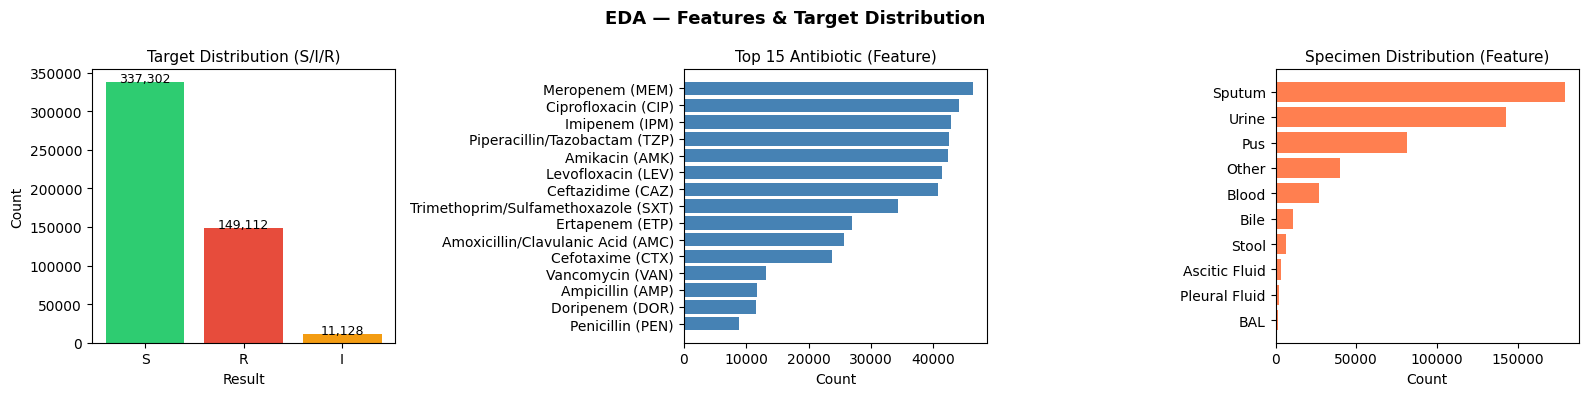


  สรุป EDA → Non-linear:
  → Target : S/I/R (3 classes)
  → S ~70%, R ~28%, I ~2% (imbalanced)
  → Features: ยา, specimen, เพศ, อายุ, ward
  → เลือก: Decision Tree, Random Forest,
            XGBoost, CatBoost



In [ ]:
# ─────────────────────────────────────────────
# STEP 6.2 — EDA
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.2 — EDA : Feature Distribution")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

result_counts = df['anti_result_clean'].value_counts()
axes[0].bar(result_counts.index, result_counts.values,
            color=['#2ecc71','#e74c3c','#f39c12'])
axes[0].set_title('Target Distribution (S/I/R)', fontsize=11)
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Count')
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

top_drugs = df['anti_name_clean'].value_counts().head(15)
axes[1].barh(top_drugs.index[::-1], top_drugs.values[::-1],
             color='steelblue')
axes[1].set_title('Top 15 Antibiotic (Feature)', fontsize=11)
axes[1].set_xlabel('Count')

spec_counts = df['specimen_clean'].value_counts().head(10)
axes[2].barh(spec_counts.index[::-1], spec_counts.values[::-1],
             color='coral')
axes[2].set_title('Specimen Distribution (Feature)', fontsize=11)
axes[2].set_xlabel('Count')

plt.suptitle('EDA — Features & Target Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
  สรุป EDA → Non-linear:
  → Target : S/I/R (3 classes)
  → S ~70%, R ~28%, I ~2% (imbalanced)
  → Features: ยา, specimen, เพศ, อายุ, ward
  → เลือก: Decision Tree, Random Forest,
            XGBoost, CatBoost
""")


# ─────────────────────────────────────────────
# ฟังก์ชัน Plot Learning Curve
# ─────────────────────────────────────────────
def plot_learning_curve(train_sizes, train_scores, valid_scores,
                        title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1),
             label='Training Accuracy', color='steelblue', lw=2)
    plt.plot(train_sizes, valid_scores.mean(axis=1),
             label='Validation Accuracy', color='orange', lw=2)
    plt.fill_between(train_sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes,
        valid_scores.mean(axis=1) - valid_scores.std(axis=1),
        valid_scores.mean(axis=1) + valid_scores.std(axis=1),
        alpha=0.1, color='orange')
    plt.title(f'Training vs Validation Accuracy ({title})',
              fontsize=13)
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


# ─────────────────────────────────────────────
# ฟังก์ชัน Plot Confusion Matrix (S/I/R)
# ─────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, filename):
    labels = ['I', 'R', 'S']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels,
                annot_kws={'size': 12})
    plt.title(f'Confusion Matrix — {title}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


# ─────────────────────────────────────────────
# ฟังก์ชัน แสดง Top 3 S/I/R Ranking
# ─────────────────────────────────────────────
def show_sir_ranking(model, X_test, y_test,
                     classes, model_name, is_catboost=False):
    """
    แสดง Top 3 S/I/R probability เรียงจาก % มากสุด
    """
    if is_catboost:
        proba = model.predict_proba(X_test)
        class_list = model.classes_
    else:
        proba = model.predict_proba(X_test)
        class_list = classes

    # คำนวณ mean probability ของ Test set ทั้งหมด
    mean_proba = proba.mean(axis=0)

    results = []
    for cls, pct in zip(class_list, mean_proba):
        results.append({'Result': cls, 'Pct': round(pct * 100, 1)})

    results = sorted(results, key=lambda x: x['Pct'], reverse=True)

    print(f"\n  {'─'*40}")
    print(f"  {model_name} — S/I/R Ranking (Test set mean)")
    print(f"  {'─'*40}")
    for i, r in enumerate(results, start=1):
        bar = '█' * int(r['Pct'] / 5)
        print(f"  อันดับ {i} → {r['Result']}  "
              f"{r['Pct']:5.1f}%  {bar}")
    print(f"  {'─'*40}")


summary = {}

##STEP 6.3 — Decision Tree


  STEP 6.3 — Decision Tree


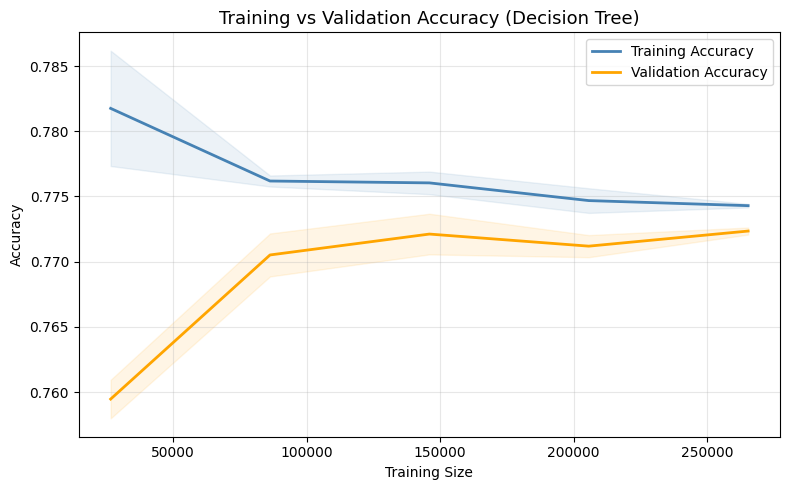


  Accuracy  : 77.09%

  Classification Report:
              precision    recall  f1-score   support

           I       0.61      0.01      0.02      2226
           R       0.70      0.54      0.61     29822
           S       0.79      0.90      0.84     67461

    accuracy                           0.77     99509
   macro avg       0.70      0.48      0.49     99509
weighted avg       0.76      0.77      0.75     99509



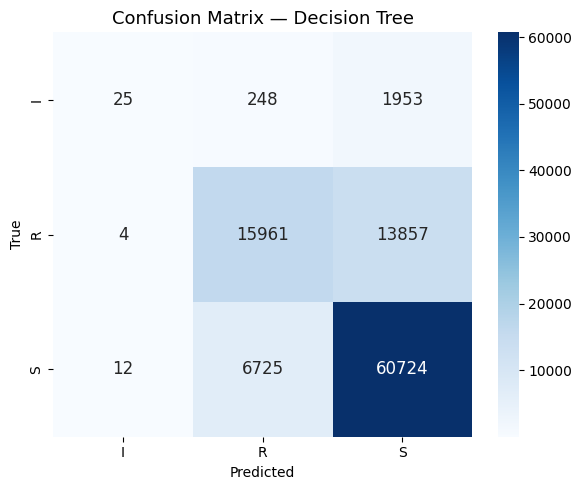


  ────────────────────────────────────────
  Decision Tree — S/I/R Ranking (Test set mean)
  ────────────────────────────────────────
  อันดับ 1 → S   67.7%  █████████████
  อันดับ 2 → R   30.0%  ██████
  อันดับ 3 → I    2.2%  
  ────────────────────────────────────────


In [ ]:
# ─────────────────────────────────────────────
# STEP 6.3 — Decision Tree
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.3 — Decision Tree")
print("="*60)

dt = DecisionTreeClassifier(max_depth=10, random_state=42)

sizes, tr_sc, val_sc = learning_curve(
    dt, X_enc_train, y_enc_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5))
plot_learning_curve(sizes, tr_sc, val_sc,
                    'Decision Tree', 'lc_dt.png')

dt.fit(X_enc_train, y_enc_train)
dt_pred = dt.predict(X_enc_test)
dt_acc  = accuracy_score(y_enc_test, dt_pred)
dt_report = classification_report(y_enc_test, dt_pred,
                target_names=le_result.classes_,
                zero_division=0, output_dict=True)

print(f"\n  Accuracy  : {dt_acc*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_enc_test, dt_pred,
        target_names=le_result.classes_, zero_division=0))

dt_pred_str = le_result.inverse_transform(dt_pred)
plot_confusion_matrix(y_test, dt_pred_str,
                      'Decision Tree', 'cm_dt.png')

show_sir_ranking(dt, X_enc_test,
                 y_enc_test, le_result.classes_,
                 'Decision Tree')

summary['Decision Tree'] = {
    'Test Accuracy': dt_acc,
    'Precision'    : dt_report['macro avg']['precision'],
    'Recall'       : dt_report['macro avg']['recall'],
    'F1-score'     : dt_report['macro avg']['f1-score']}

##STEP 6.4 — Random Forest


  STEP 6.4 — Random Forest


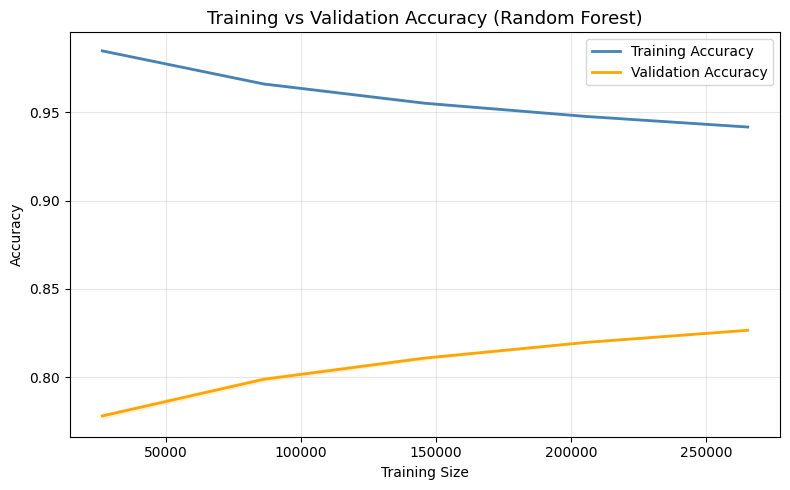


  Accuracy  : 83.55%

  Classification Report:
              precision    recall  f1-score   support

           I       0.31      0.16      0.21      2226
           R       0.76      0.75      0.75     29822
           S       0.87      0.90      0.89     67461

    accuracy                           0.84     99509
   macro avg       0.65      0.60      0.62     99509
weighted avg       0.83      0.84      0.83     99509



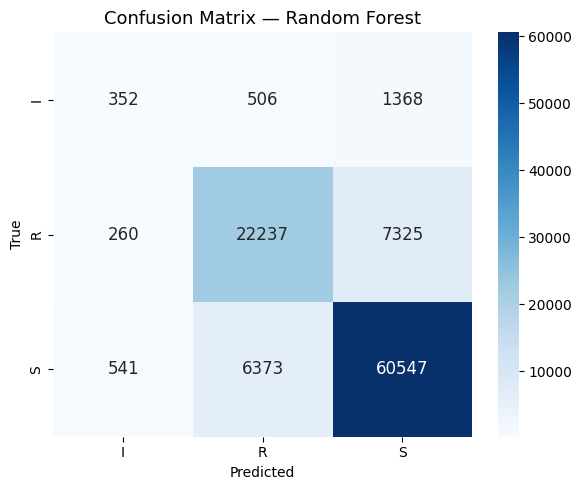


  ────────────────────────────────────────
  Random Forest — S/I/R Ranking (Test set mean)
  ────────────────────────────────────────
  อันดับ 1 → S   67.2%  █████████████
  อันดับ 2 → R   30.5%  ██████
  อันดับ 3 → I    2.3%  
  ────────────────────────────────────────


In [ ]:
# ─────────────────────────────────────────────
# STEP 6.4 — Random Forest
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.4 — Random Forest")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)

sizes, tr_sc, val_sc = learning_curve(
    rf, X_enc_train, y_enc_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5))
plot_learning_curve(sizes, tr_sc, val_sc,
                    'Random Forest', 'lc_rf.png')

rf.fit(X_enc_train, y_enc_train)
rf_pred = rf.predict(X_enc_test)
rf_acc  = accuracy_score(y_enc_test, rf_pred)
rf_report = classification_report(y_enc_test, rf_pred,
                target_names=le_result.classes_,
                zero_division=0, output_dict=True)

print(f"\n  Accuracy  : {rf_acc*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_enc_test, rf_pred,
        target_names=le_result.classes_, zero_division=0))

rf_pred_str = le_result.inverse_transform(rf_pred)
plot_confusion_matrix(y_test, rf_pred_str,
                      'Random Forest', 'cm_rf.png')

show_sir_ranking(rf, X_enc_test,
                 y_enc_test, le_result.classes_,
                 'Random Forest')

summary['Random Forest'] = {
    'Test Accuracy': rf_acc,
    'Precision'    : rf_report['macro avg']['precision'],
    'Recall'       : rf_report['macro avg']['recall'],
    'F1-score'     : rf_report['macro avg']['f1-score']}

##STEP 6.5 — XGBoost


  STEP 6.5 — XGBoost


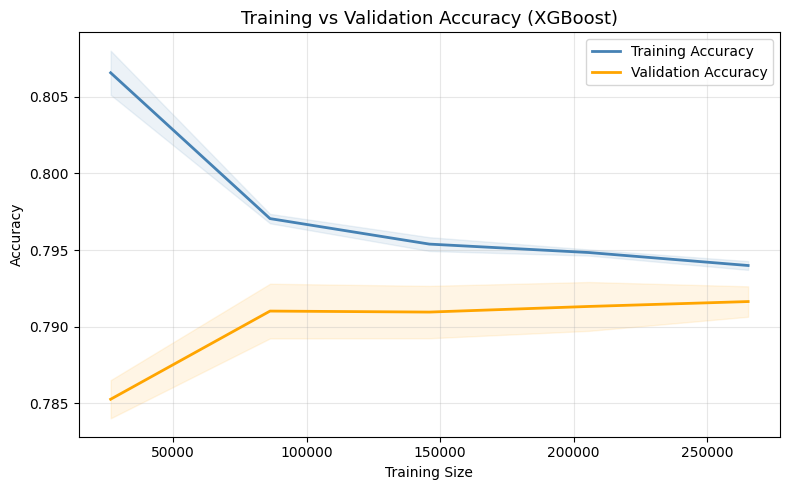


  Accuracy  : 79.10%

  Classification Report:
              precision    recall  f1-score   support

           I       0.74      0.01      0.02      2226
           R       0.75      0.56      0.64     29822
           S       0.80      0.92      0.86     67461

    accuracy                           0.79     99509
   macro avg       0.76      0.50      0.51     99509
weighted avg       0.79      0.79      0.77     99509



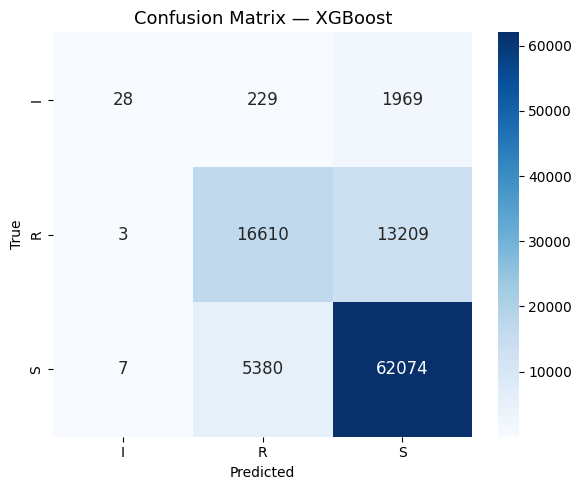


  ────────────────────────────────────────
  XGBoost — S/I/R Ranking (Test set mean)
  ────────────────────────────────────────
  อันดับ 1 → S   67.8%  █████████████
  อันดับ 2 → R   30.0%  ██████
  อันดับ 3 → I    2.2%  
  ────────────────────────────────────────


In [ ]:
# ─────────────────────────────────────────────
# STEP 6.5 — XGBoost
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.5 — XGBoost")
print("="*60)

xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=6, random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss', n_jobs=-1)

sizes, tr_sc, val_sc = learning_curve(
    xgb, X_enc_train, y_enc_train,
    cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5))
plot_learning_curve(sizes, tr_sc, val_sc,
                    'XGBoost', 'lc_xgb.png')

xgb.fit(X_enc_train, y_enc_train)
xgb_pred = xgb.predict(X_enc_test)
xgb_acc  = accuracy_score(y_enc_test, xgb_pred)
xgb_report = classification_report(y_enc_test, xgb_pred,
                target_names=le_result.classes_,
                zero_division=0, output_dict=True)

print(f"\n  Accuracy  : {xgb_acc*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_enc_test, xgb_pred,
        target_names=le_result.classes_, zero_division=0))

xgb_pred_str = le_result.inverse_transform(xgb_pred)
plot_confusion_matrix(y_test, xgb_pred_str,
                      'XGBoost', 'cm_xgb.png')

show_sir_ranking(xgb, X_enc_test,
                 y_enc_test, le_result.classes_,
                 'XGBoost')

summary['XGBoost'] = {
    'Test Accuracy': xgb_acc,
    'Precision'    : xgb_report['macro avg']['precision'],
    'Recall'       : xgb_report['macro avg']['recall'],
    'F1-score'     : xgb_report['macro avg']['f1-score']}


##STEP 6.6 — CatBoost


  STEP 6.6 — CatBoost (string + numeric)

  Accuracy  : 78.05%

  Classification Report:
              precision    recall  f1-score   support

           I       0.77      0.00      0.01      2226
           R       0.70      0.58      0.64     29822
           S       0.81      0.89      0.85     67461

    accuracy                           0.78     99509
   macro avg       0.76      0.49      0.50     99509
weighted avg       0.77      0.78      0.77     99509



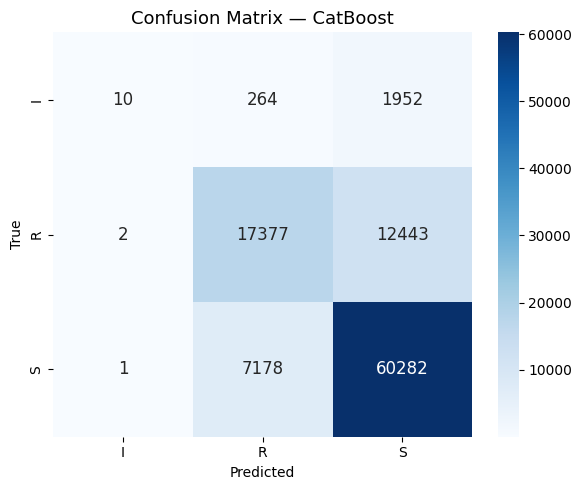


  ────────────────────────────────────────
  CatBoost — S/I/R Ranking (Test set mean)
  ────────────────────────────────────────
  อันดับ 1 → S   67.8%  █████████████
  อันดับ 2 → R   30.0%  ██████
  อันดับ 3 → I    2.2%  
  ────────────────────────────────────────


In [ ]:
# ─────────────────────────────────────────────
# STEP 6.6 — CatBoost
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.6 — CatBoost (string + numeric)")
print("="*60)

cat_model = CatBoostClassifier(
    iterations=100, learning_rate=0.1, depth=6,
    random_seed=42,
    cat_features=cat_features_str,
    verbose=0)

cat_model.fit(X_cat_train, y_train)
cat_pred = np.array(cat_model.predict(X_cat_test)).flatten()
cat_acc  = accuracy_score(y_test, cat_pred)
cat_report = classification_report(y_test, cat_pred,
                zero_division=0, output_dict=True)

print(f"\n  Accuracy  : {cat_acc*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_test, cat_pred, zero_division=0))

plot_confusion_matrix(y_test, cat_pred,
                      'CatBoost', 'cm_catboost.png')

show_sir_ranking(cat_model, X_cat_test,
                 y_test, None,
                 'CatBoost', is_catboost=True)

summary['CatBoost'] = {
    'Test Accuracy': cat_acc,
    'Precision'    : cat_report['macro avg']['precision'],
    'Recall'       : cat_report['macro avg']['recall'],
    'F1-score'     : cat_report['macro avg']['f1-score']}

In [ ]:
"""# ─────────────────────────────────────────────
# STEP 6.6 — CatBoost
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.6 — CatBoost (string + numeric)")
print("="*60)

cat_features_idx = ['specimen_clean',
                    'org_clean_final',
                    'anti_result_clean']

cat_model = CatBoostClassifier(
    iterations=100, learning_rate=0.1, depth=6,
    random_seed=42,
    cat_features=cat_features_idx,
    verbose=0)

# Learning Curve CatBoost
skf_lc = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
train_size_list = np.linspace(0.1, 1.0, 5)
lc_tr, lc_val, lc_sizes = [], [], []

for size in train_size_list:
    n = int(len(X_cat_train) * size)
    lc_sizes.append(n)
    fold_tr, fold_val = [], []
    for tr_idx, val_idx in skf_lc.split(
            X_cat_train.iloc[:n], y_train.iloc[:n]):
        X_tr  = X_cat_train.iloc[:n].iloc[tr_idx]
        y_tr  = y_train.iloc[:n].iloc[tr_idx]
        X_val = X_cat_train.iloc[:n].iloc[val_idx]
        y_val = y_train.iloc[:n].iloc[val_idx]
        m = CatBoostClassifier(
            iterations=100, learning_rate=0.1, depth=6,
            random_seed=42,
            cat_features=cat_features_idx,
            verbose=0)
        m.fit(X_tr, y_tr)
        fold_tr.append(accuracy_score(y_tr, m.predict(X_tr)))
        fold_val.append(accuracy_score(y_val, m.predict(X_val)))
    lc_tr.append(fold_tr)
    lc_val.append(fold_val)

plot_learning_curve(
    np.array(lc_sizes),
    np.array(lc_tr),
    np.array(lc_val),
    'CatBoost', 'lc_catboost.png')

cat_model.fit(X_cat_train, y_train)
cat_pred   = np.array(cat_model.predict(X_cat_test)).flatten()
cat_acc    = accuracy_score(y_test, cat_pred)
cat_report = classification_report(y_test, cat_pred,
                zero_division=0, output_dict=True)

print(f"\n  Accuracy  : {cat_acc*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_test, cat_pred, zero_division=0))

plot_confusion_matrix(y_test, cat_pred,
                      'CatBoost', 'cm_catboost.png')

summary['CatBoost'] = {
    'Test Accuracy': cat_acc,
    'Precision'    : cat_report['macro avg']['precision'],
    'Recall'       : cat_report['macro avg']['recall'],
    'F1-score'     : cat_report['macro avg']['f1-score'],
    'y_pred_str'   : cat_pred}
"""

'# ─────────────────────────────────────────────\n# STEP 6.6 — CatBoost\n# ─────────────────────────────────────────────\nprint("\n" + "="*60)\nprint("  STEP 6.6 — CatBoost (string + numeric)")\nprint("="*60)\n\ncat_features_idx = [\'specimen_clean\',\n                    \'org_clean_final\',\n                    \'anti_result_clean\']\n\ncat_model = CatBoostClassifier(\n    iterations=100, learning_rate=0.1, depth=6,\n    random_seed=42,\n    cat_features=cat_features_idx,\n    verbose=0)\n\n# Learning Curve CatBoost\nskf_lc = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)\ntrain_size_list = np.linspace(0.1, 1.0, 5)\nlc_tr, lc_val, lc_sizes = [], [], []\n\nfor size in train_size_list:\n    n = int(len(X_cat_train) * size)\n    lc_sizes.append(n)\n    fold_tr, fold_val = [], []\n    for tr_idx, val_idx in skf_lc.split(\n            X_cat_train.iloc[:n], y_train.iloc[:n]):\n        X_tr  = X_cat_train.iloc[:n].iloc[tr_idx]\n        y_tr  = y_train.iloc[:n].iloc[tr_idx]\n    

## STEP 6.7 — เปรียบเทียบทุก Model


  STEP 6.7 — Model Comparison
  Model              Test Acc   Precision   Recall       F1
  -------------------------------------------------------
  Decision Tree        0.7709      0.6997   0.4822   0.4902
  Random Forest        0.8355      0.6478   0.6004   0.6163 ✅
  XGBoost              0.7910      0.7626   0.4966   0.5070
  CatBoost             0.7805      0.7589   0.4936   0.4977


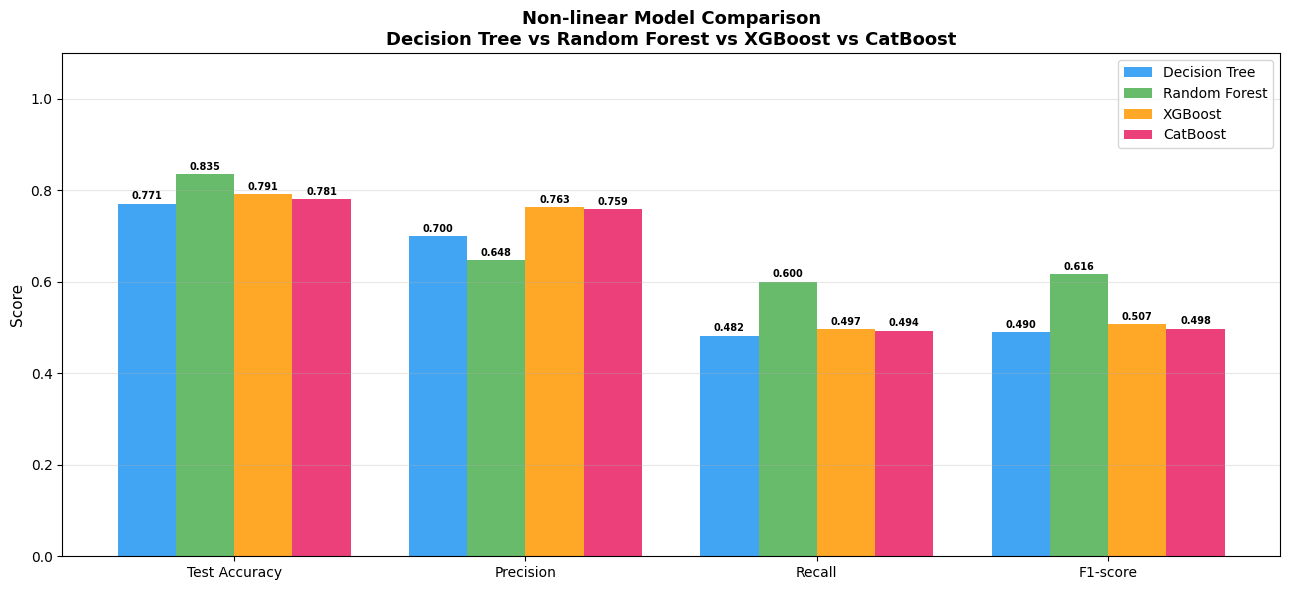

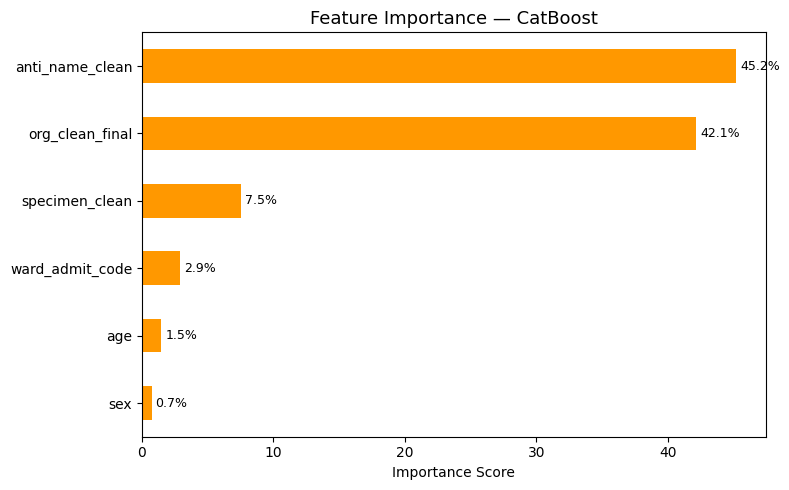


  Best Model : Random Forest
  Test Accuracy : 83.55%
  Macro F1      : 0.6163


In [ ]:
# ─────────────────────────────────────────────
# STEP 6.7 — Model Comparison
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("  STEP 6.7 — Model Comparison")
print("="*60)

print(f"  {'Model':<16} {'Test Acc':>10} "
      f"{'Precision':>11} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*55}")

best_name = max(summary, key=lambda k: summary[k]['Test Accuracy'])
for name, res in summary.items():
    marker = ' ✅' if name == best_name else ''
    print(f"  {name:<16} {res['Test Accuracy']:>10.4f} "
          f"{res['Precision']:>11.4f} "
          f"{res['Recall']:>8.4f} "
          f"{res['F1-score']:>8.4f}{marker}")

# Bar Chart
metrics     = ['Test Accuracy','Precision','Recall','F1-score']
model_names = list(summary.keys())
x      = np.arange(len(metrics))
width  = 0.2
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [summary[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Non-linear Model Comparison\n'
             'Decision Tree vs Random Forest vs XGBoost vs CatBoost',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Feature Importance — CatBoost
feat_names = cat_features_str + num_features
feat_imp = pd.Series(
    cat_model.get_feature_importance(),
    index=feat_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='#FF9800')
plt.title('Feature Importance — CatBoost', fontsize=13)
plt.xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n  Best Model : {best_name}")
print(f"  Test Accuracy : "
      f"{summary[best_name]['Test Accuracy']*100:.2f}%")
print(f"  Macro F1      : {summary[best_name]['F1-score']:.4f}")
print("="*60)